In [1]:
import pandas as pd
import sklearn
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
import numpy as np

In [2]:
# pip install numpy==1.26.4

In [3]:
# pip install tensorflow==2.16.1 keras==3.3.3

In [4]:
df = pd.read_excel("/content/Major Data.xlsx")

In [5]:
df.head()

,Ion,Material - 1,Material - 2,Operating temperature(K),Initial pH,Initial Conc. (ppm),Contact time(min),Adsorbent dosage(g),Solution,Removal efficiency(%)
0,Cr,Bentonite,Magnetite,298,1.5,55,60,1.50,Aqueous,85.7
1,Cr,Bentonite,Magnetite,298,2.5,25,120,1.00,Aqueous,90.7
2,Cr,Bentonite,Magnetite,298,1.0,40,90,1.25,Aqueous,90.7
3,Cr,Bentonite,Magnetite,298,2.5,25,120,1.50,Aqueous,92.2
4,Cr,Bentonite,Magnetite,298,2.0,40,90,1.25,Aqueous,96.3


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279 entries, 0 to 278
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Ion                       279 non-null    object 
 1   Material - 1              279 non-null    object 
 2   Material - 2              279 non-null    object 
 3   Operating temperature(K)  279 non-null    int64  
 4   Initial pH                279 non-null    float64
 5   Initial Conc. (ppm)       279 non-null    int64  
 6   Contact time(min)         279 non-null    int64  
 7   Adsorbent dosage(g)       279 non-null    float64
 8   Solution                  279 non-null    object 
 9   Removal efficiency(%)     279 non-null    float64
dtypes: float64(3), int64(3), object(4)
memory usage: 21.9+ KB


In [7]:
df.describe()

,Operating temperature(K),Initial pH,Initial Conc. (ppm),Contact time(min),Adsorbent dosage(g),Removal efficiency(%)
count,279.000000,279.000000,279.000000,279.000000,279.000000,279.000000
mean,299.017921,3.666237,53.154122,138.924731,1.110448,78.338280
std,3.908536,2.386164,62.175036,175.728979,0.796949,21.682375
min,287.000000,1.000000,5.000000,5.000000,0.005000,4.280000
25%,298.000000,2.000000,10.000000,60.000000,0.500000,70.000000
50%,298.000000,3.000000,40.000000,90.000000,1.000000,85.630000
75%,303.000000,5.000000,50.000000,120.000000,1.250000,95.875000
max,313.000000,13.000000,300.000000,720.000000,5.000000,100.000000


In [8]:
df.isnull().sum()

,0
Ion,0
Material - 1,0
Material - 2,0
Operating temperature(K),0
Initial pH,0
Initial Conc. (ppm),0
Contact time(min),0
Adsorbent dosage(g),0
Solution,0
Removal efficiency(%),0


<Figure size 1200x800 with 0 Axes>

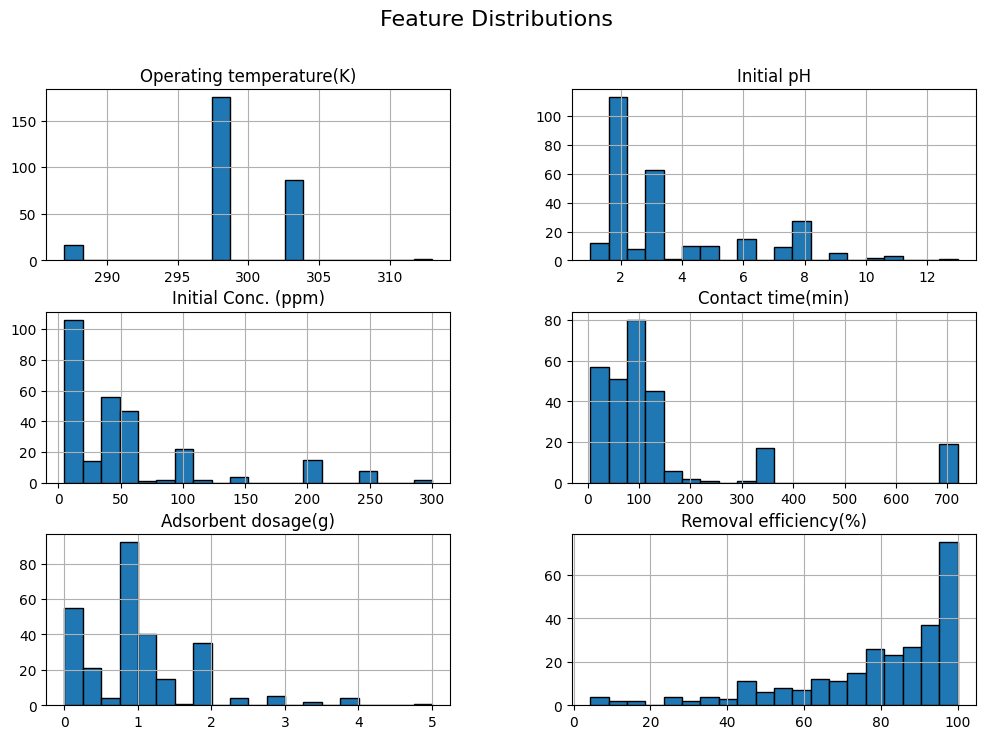

In [9]:
plt.figure(figsize=(12, 8))
df.hist(figsize=(12, 8), bins=20, edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

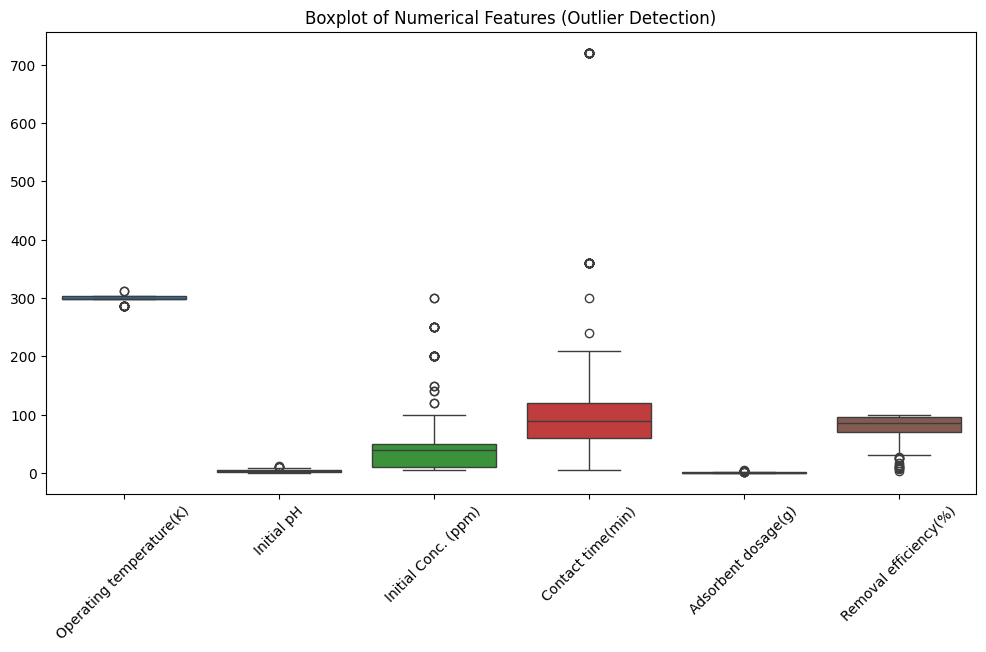

In [10]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.select_dtypes(include=[np.number]))
plt.xticks(rotation=45)
plt.title("Boxplot of Numerical Features (Outlier Detection)")
plt.show()

In [11]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

num_cols = ["Initial Conc. (ppm)", "Contact time(min)", "Adsorbent dosage(g)"]
for col in num_cols:
    df = remove_outliers(df, col)

print(f"Dataset size after outlier removal: {df.shape}")

Dataset size after outlier removal: (205, 10)


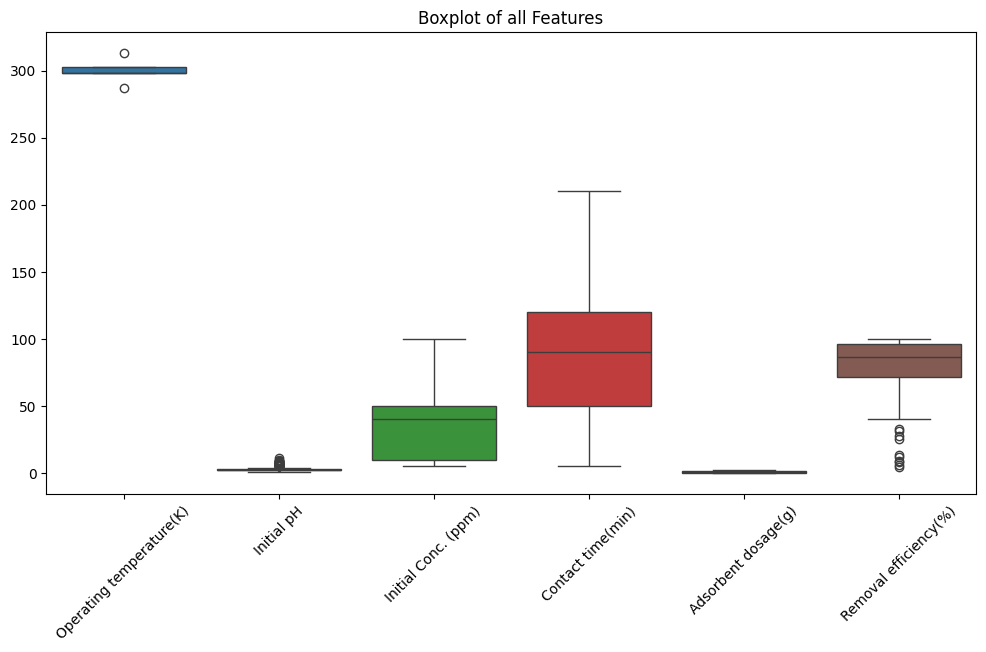

In [12]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Boxplot of all Features")
plt.show()


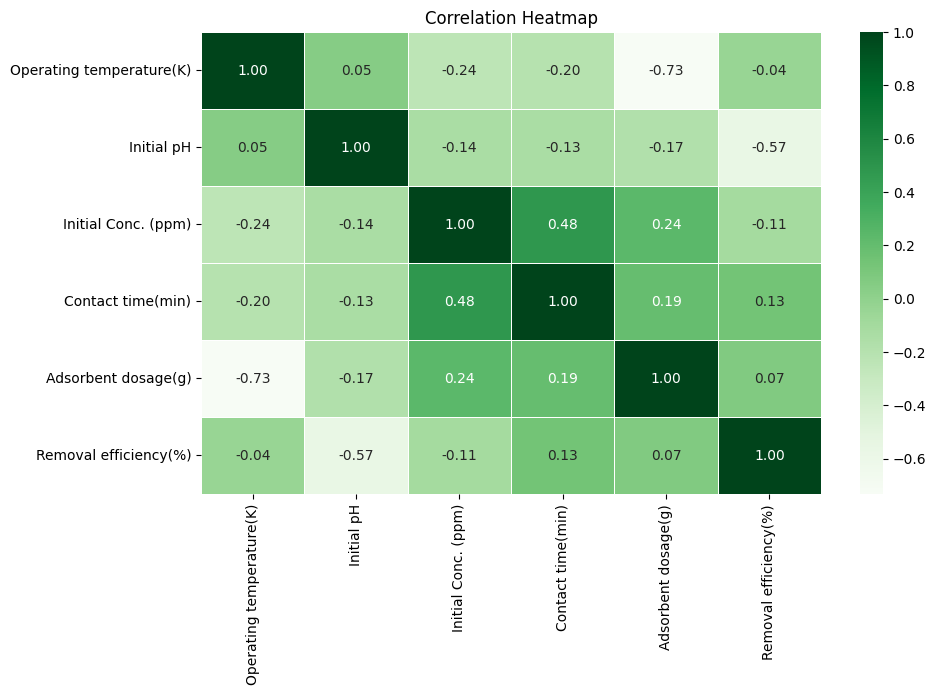

In [13]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='Greens', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


In [14]:
categorical_cols = ["Ion", "Material - 1", "Material - 2", "Solution"]
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("Categorical variables encoded successfully.")


Categorical variables encoded successfully.


In [15]:
df

,Ion,Material - 1,Material - 2,Operating temperature(K),Initial pH,Initial Conc. (ppm),Contact time(min),Adsorbent dosage(g),Solution,Removal efficiency(%)
0,0,1,5,298,1.5,55,60,1.50,0,85.70
1,0,1,5,298,2.5,25,120,1.00,0,90.70
2,0,1,5,298,1.0,40,90,1.25,0,90.70
3,0,1,5,298,2.5,25,120,1.50,0,92.20
4,0,1,5,298,2.0,40,90,1.25,0,96.30
...,...,...,...,...,...,...,...,...,...,...
260,0,4,2,298,3.0,100,20,1.00,0,71.50
261,0,4,2,298,3.0,100,40,1.00,0,72.20
262,0,4,2,298,3.0,100,60,1.00,0,76.60
263,0,4,2,298,3.0,100,120,1.00,0,76.75


<Figure size 1200x800 with 0 Axes>

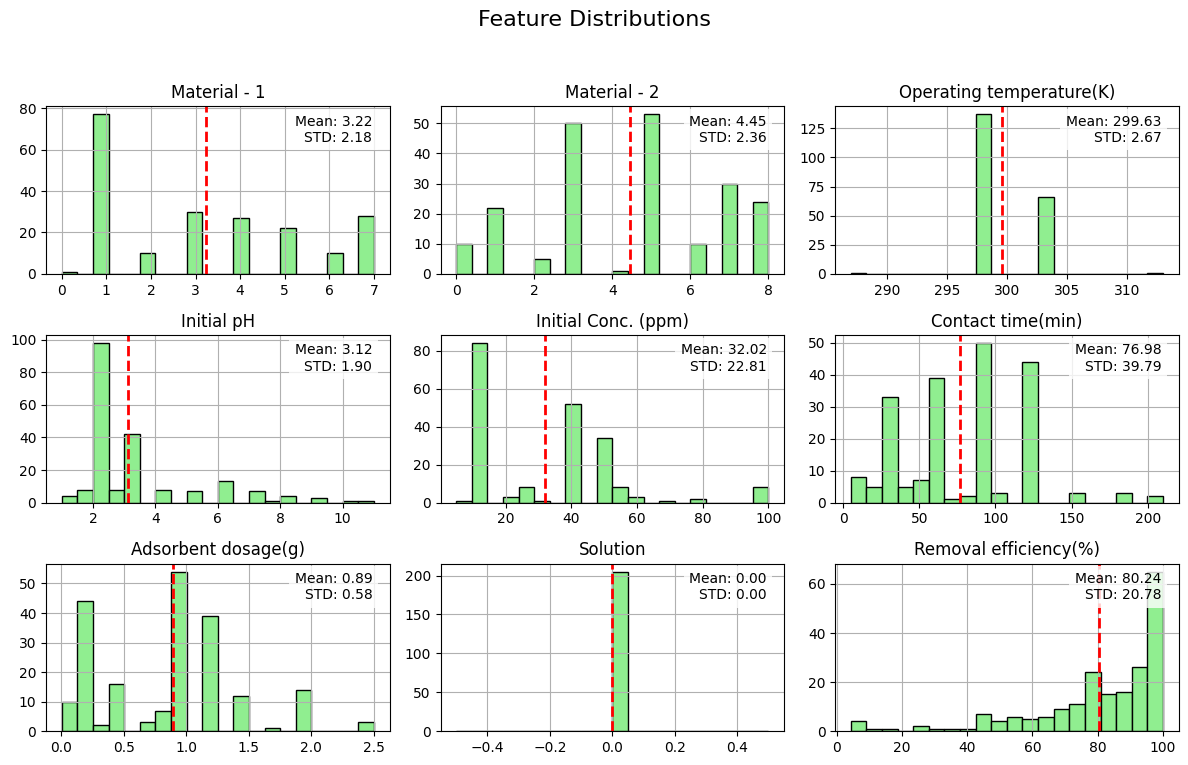

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Create a copy of the dataframe without the 'iom' column
df_plot = df.drop('Ion', axis=1)

plt.figure(figsize=(12, 8))

# Create histograms with light green color
axes = df_plot.hist(figsize=(12, 8), bins=20, edgecolor='black', color='lightgreen')

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Add mean and std annotations to each subplot
for ax, column in zip(axes, df_plot.columns):
    mean = df_plot[column].mean()
    std = df_plot[column].std()
    ax.axvline(mean, color='red', linestyle='dashed', linewidth=2)
    ax.text(0.95, 0.95, f'Mean: {mean:.2f}\nSTD: {std:.2f}',
            transform=ax.transAxes, ha='right', va='top',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to prevent overlap
plt.show()

<ipython-input-17-e438dcbedabf>:40: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df_plot[column], ax=ax, color='skyblue', fill=True, alpha=0.4)


<Figure size 1200x800 with 0 Axes>

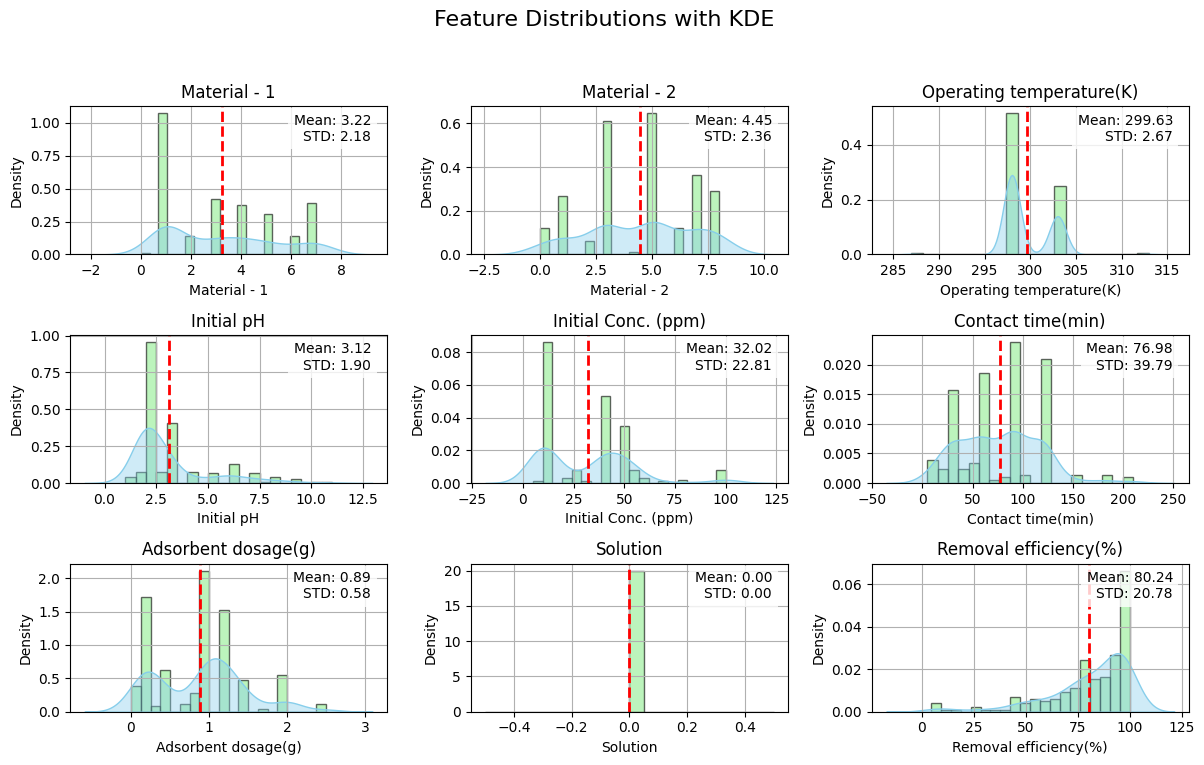

In [17]:
import pandas as pd
import sklearn
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

df_plot = df.drop('Ion', axis=1)

plt.figure(figsize=(12, 8))

axes = df_plot.hist(figsize=(12, 8), bins=20, edgecolor='black', color='lightgreen', density=True, alpha=0.6)

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Add mean and std annotations to each subplot
for ax, column in zip(axes, df_plot.columns):
    mean = df_plot[column].mean()
    std = df_plot[column].std()
    ax.axvline(mean, color='red', linestyle='dashed', linewidth=2)
    ax.text(0.95, 0.95, f'Mean: {mean:.2f}\nSTD: {std:.2f}',
            transform=ax.transAxes, ha='right', va='top',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    # Plot KDE curve
    sns.kdeplot(df_plot[column], ax=ax, color='skyblue', fill=True, alpha=0.4)


plt.suptitle("Feature Distributions with KDE", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to prevent overlap
plt.show()


In [18]:
num_features = ["Operating temperature(K)", "Initial pH", "Initial Conc. (ppm)",
                "Contact time(min)", "Adsorbent dosage(g)"]

scaler = StandardScaler()
df[num_features] = scaler.fit_transform(df[num_features])

print("Numerical features standardized successfully.")


Numerical features standardized successfully.


In [19]:
X = df.drop(columns=["Removal efficiency(%)"])
y = df["Removal efficiency(%)"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}, Testing set size: {X_test.shape}")


Training set size: (164, 9), Testing set size: (41, 9)


In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = RandomForestRegressor(n_estimators=100, random_state=30)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [21]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Model Performance:
Mean Absolute Error (MAE): 5.30
Root Mean Squared Error (RMSE): 9.05
R² Score: 0.7804


In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define parameter grid
param_grid = {
    "n_estimators": [10, 100, 500],
    "max_depth": [None, 5, 10, 20],
    "max_features": ['sqrt', 'log2'],  # Fixed missing comma
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Initialize Random Forest model
rf = RandomForestRegressor(random_state=42)

# Perform Grid Search
grid_search = GridSearchCV(
    rf, param_grid, cv=5, scoring="r2", n_jobs=-1, verbose=2
)
grid_search.fit(X_train, y_train)

# Get best model
best_rf = grid_search.best_estimator_

# Make predictions
y_pred_best = best_rf.predict(X_test)

# Evaluate model performance
mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = mean_squared_error(y_test, y_pred_best) ** 0.5
r2_best = r2_score(y_test, y_pred_best)

# Print results
print("Best Hyperparameters:", grid_search.best_params_)
print("\nOptimized Model Performance:")
print(f"Mean Absolute Error (MAE): {mae_best:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_best:.2f}")
print(f"R² Score: {r2_best:.4f}")


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Hyperparameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}

Optimized Model Performance:
Mean Absolute Error (MAE): 5.53
Root Mean Squared Error (RMSE): 8.37
R² Score: 0.8124


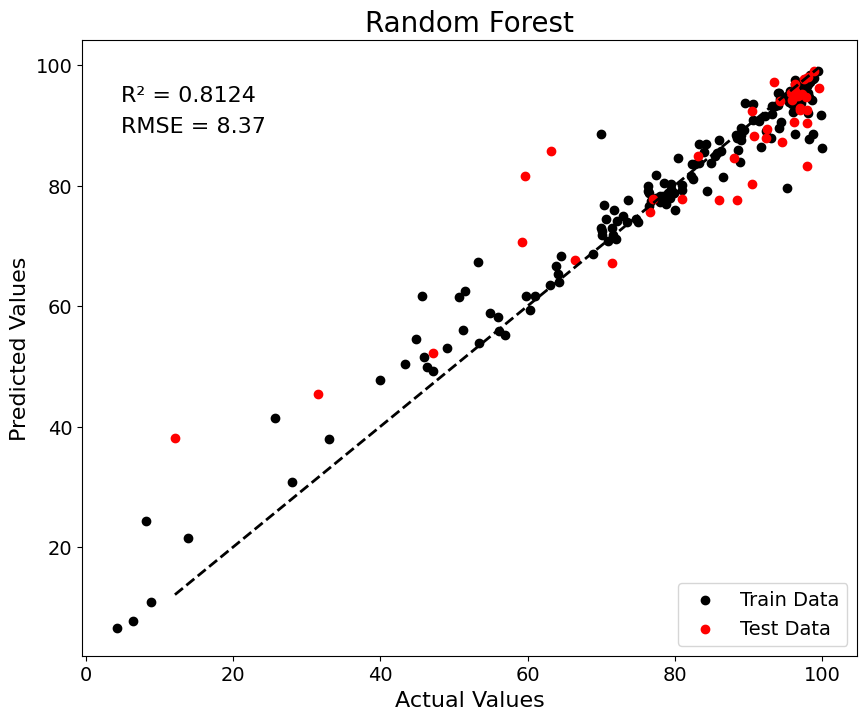

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.scatter(y_train, best_rf.predict(X_train), color='black', label='Train Data')
plt.scatter(y_test, y_pred_best, color='red', label='Test Data')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Values', fontsize=16)
plt.ylabel('Predicted Values', fontsize=16)
plt.title('Random Forest', fontsize=20)
plt.legend(fontsize=14, loc='lower right')

plt.text(0.05, 0.9, f"R² = {r2_best:.4f}", transform=plt.gca().transAxes, fontsize=16)
plt.text(0.05, 0.85, f"RMSE = {rmse_best:.2f}", transform=plt.gca().transAxes, fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

<ipython-input-24-3cdc05d131d3>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=feature_names, palette="coolwarm")


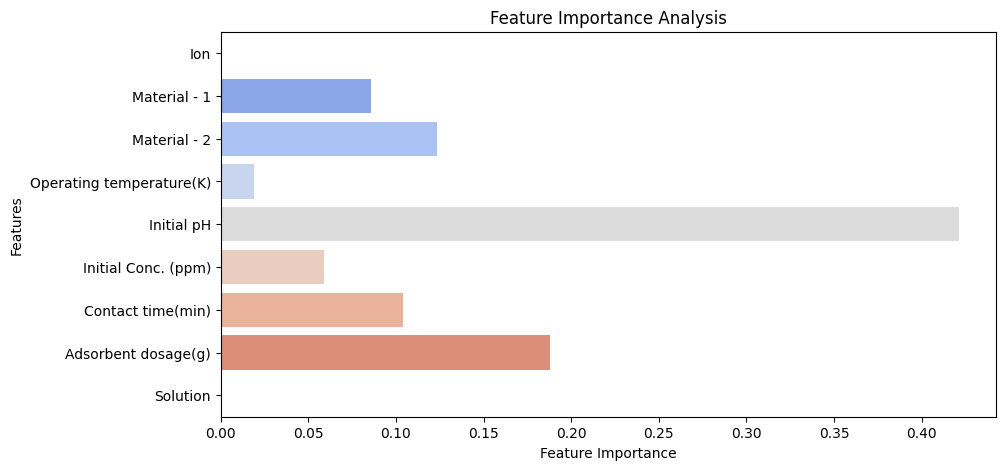

In [24]:
importances = best_rf.feature_importances_
feature_names = X_train.columns

plt.figure(figsize=(10, 5))
sns.barplot(x=importances, y=feature_names, palette="coolwarm")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance Analysis")
plt.show()

In [25]:
from xgboost import XGBRegressor

# Train XGBoost model
xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = mean_squared_error(y_test, y_pred_xgb) ** 0.5
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Model Performance:")
print(f"Mean Absolute Error (MAE): {mae_xgb:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.2f}")
print(f"R² Score: {r2_xgb:.4f}")


XGBoost Model Performance:
Mean Absolute Error (MAE): 4.91
Root Mean Squared Error (RMSE): 8.54
R² Score: 0.8047


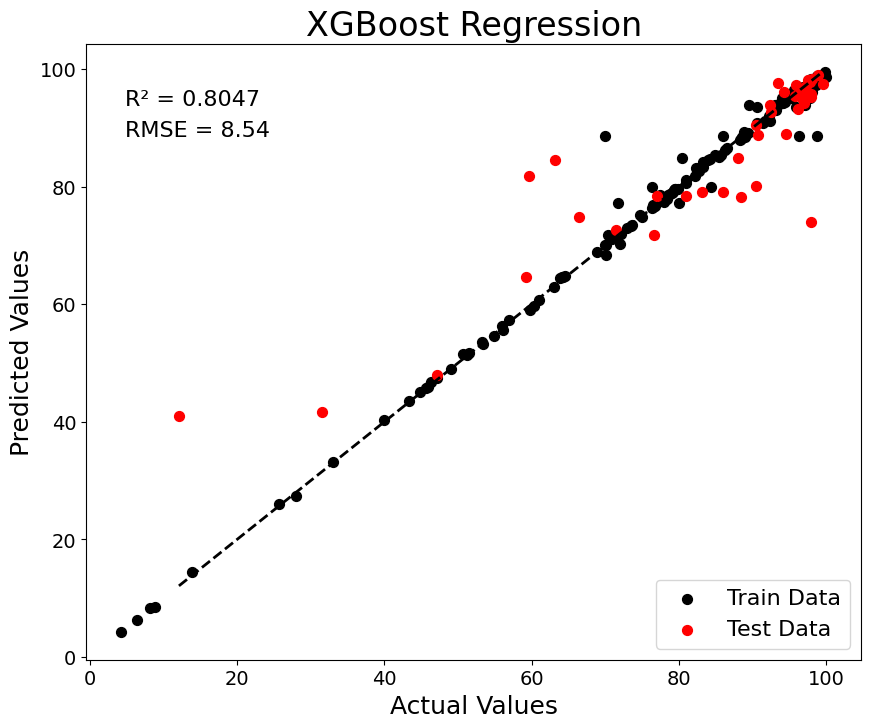

In [26]:
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Predictions on train and test data using xgb_model
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb = xgb_model.predict(X_test)

# Calculate R² and RMSE for test data
r2_xgb = r2_score(y_test, y_test_pred_xgb)
rmse_xgb = mean_squared_error(y_test, y_test_pred_xgb) ** 0.5

# Plotting Actual vs Predicted values
plt.figure(figsize=(10, 8))
plt.scatter(y_train, y_train_pred_xgb, color='black', label='Train Data', s=50)
plt.scatter(y_test, y_test_pred_xgb, color='red', label='Test Data', s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)

plt.xlabel('Actual Values', fontsize=18)
plt.ylabel('Predicted Values', fontsize=18)
plt.title('XGBoost Regression', fontsize=24)
plt.legend(fontsize=16, loc='lower right')

# Display R² and RMSE on plot
plt.text(0.05, 0.9, f"R² = {r2_xgb:.4f}", transform=plt.gca().transAxes, fontsize=16)
plt.text(0.05, 0.85, f"RMSE = {rmse_xgb:.2f}", transform=plt.gca().transAxes, fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

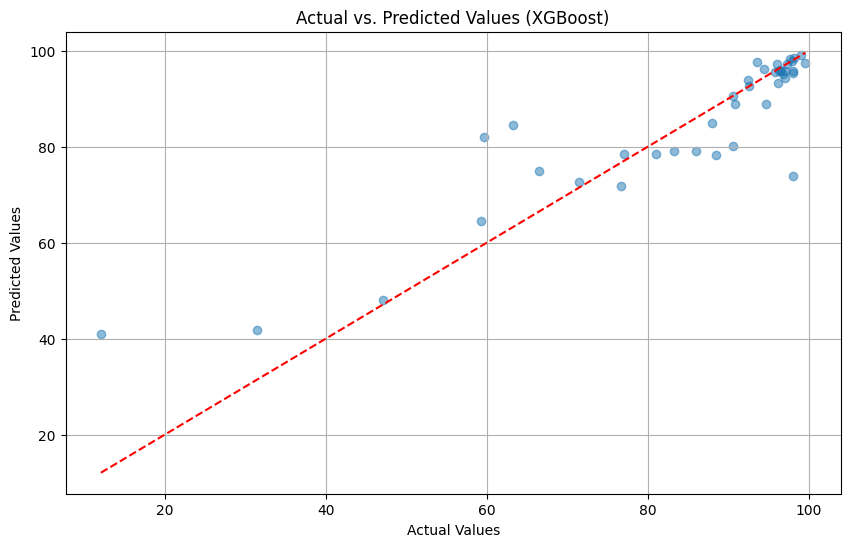

In [27]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')  # Ideal prediction line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values (XGBoost)")
plt.grid(True)
plt.show()


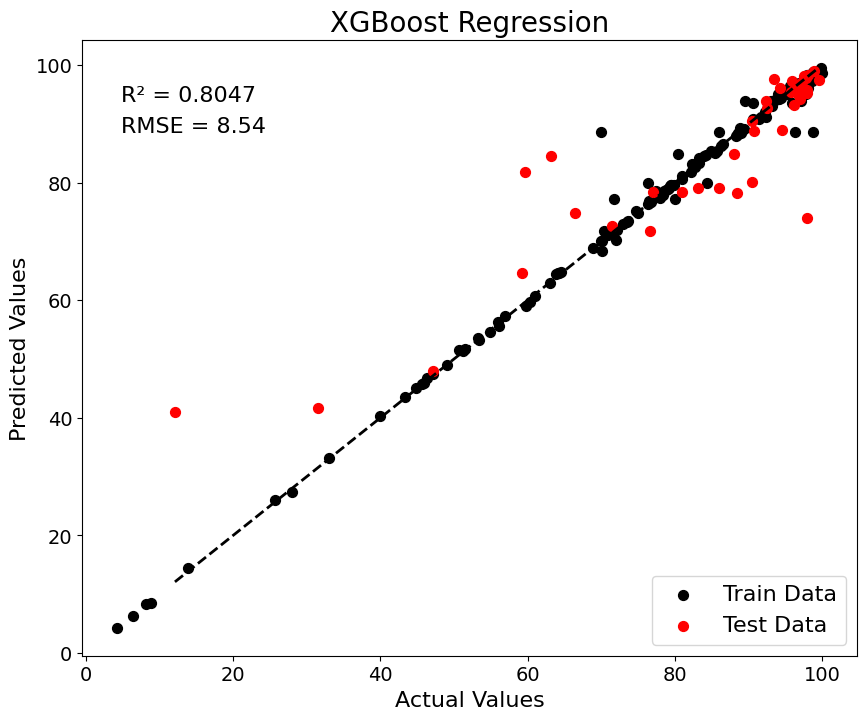

In [28]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.scatter(y_train, xgb_model.predict(X_train), color='black', label='Train Data', s=50)
plt.scatter(y_test, y_pred_xgb, color='red', label='Test Data', s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Values', fontsize=16)
plt.ylabel('Predicted Values', fontsize=16)
plt.title('XGBoost Regression', fontsize=20)
plt.legend(fontsize=16, loc='lower right')

plt.text(0.05, 0.9, f"R² = {r2_xgb:.4f}", transform=plt.gca().transAxes, fontsize=16)
plt.text(0.05, 0.85, f"RMSE = {rmse_xgb:.2f}", transform=plt.gca().transAxes, fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

In [29]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 12.7 MB/s eta 0:00:00


In [30]:
import optuna

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3)
    }
    model = XGBRegressor(**params)
    model.fit(X_train, y_train)
    return -mean_squared_error(y_test, model.predict(X_test))

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)

print("Best Parameters:", study.best_params)


[I 2025-05-01 18:50:15,306] A new study created in memory with name: no-name-e028370e-40ad-4c26-b396-bd0dff3dbd44
[I 2025-05-01 18:50:15,504] Trial 0 finished with value: -70.17559201025952 and parameters: {'n_estimators': 360, 'max_depth': 9, 'learning_rate': 0.12792231057472292}. Best is trial 0 with value: -70.17559201025952.
[I 2025-05-01 18:50:15,739] Trial 1 finished with value: -66.90302583260024 and parameters: {'n_estimators': 258, 'max_depth': 19, 'learning_rate': 0.1445020296606944}. Best is trial 0 with value: -70.17559201025952.
[I 2025-05-01 18:50:15,911] Trial 2 finished with value: -65.89876680716186 and parameters: {'n_estimators': 356, 'max_depth': 12, 'learning_rate': 0.1268035787952842}. Best is trial 0 with value: -70.17559201025952.
[I 2025-05-01 18:50:16,304] Trial 3 finished with value: -70.26046973393466 and parameters: {'n_estimators': 360, 'max_depth': 16, 'learning_rate': 0.16396858599335473}. Best is trial 3 with value: -70.26046973393466.
[I 2025-05-01 18:

Best Parameters: {'n_estimators': 302, 'max_depth': 6, 'learning_rate': 0.17343549491228133}


Optimized XGBoost Model Performance:
Mean Absolute Error (MAE): 5.20
Root Mean Squared Error (RMSE): 9.00
R² Score: 0.7827


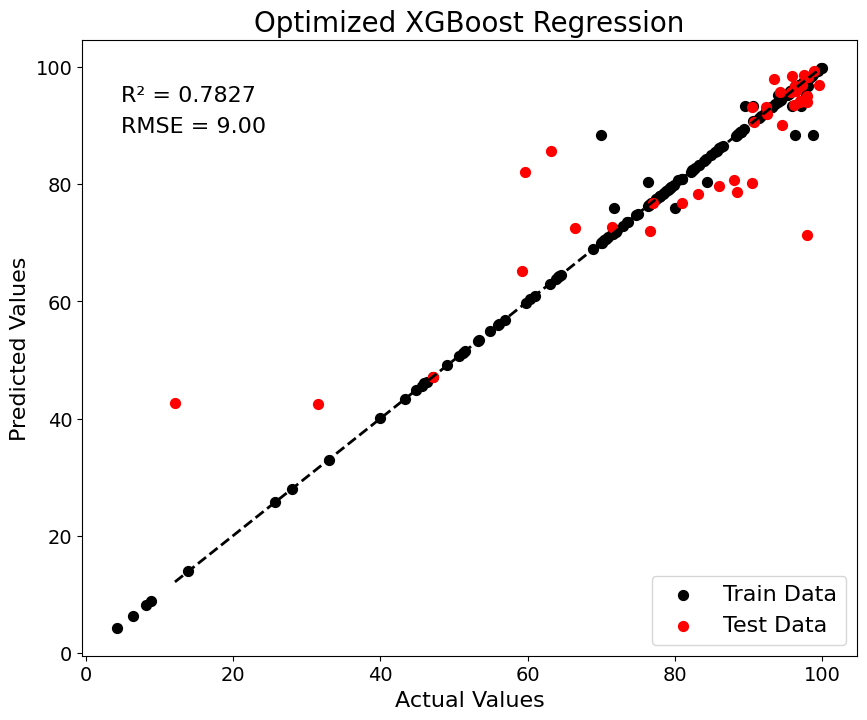

In [31]:
import matplotlib.pyplot as plt
# Get the best parameters from Optuna study
best_params = study.best_params

# Train XGBoost model with best parameters
best_xgb_model = XGBRegressor(**best_params)
best_xgb_model.fit(X_train, y_train)

# Make predictions using the optimized model
y_pred_best_xgb = best_xgb_model.predict(X_test)

# Evaluate the optimized XGBoost model
mae_best_xgb = mean_absolute_error(y_test, y_pred_best_xgb)
rmse_best_xgb = mean_squared_error(y_test, y_pred_best_xgb) ** 0.5
r2_best_xgb = r2_score(y_test, y_pred_best_xgb)


print("Optimized XGBoost Model Performance:")
print(f"Mean Absolute Error (MAE): {mae_best_xgb:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_best_xgb:.2f}")
print(f"R² Score: {r2_best_xgb:.4f}")

# Visualize the performance of the optimized model (optional)
plt.figure(figsize=(10, 8))
plt.scatter(y_train, best_xgb_model.predict(X_train), color='black', label='Train Data', s=50)
plt.scatter(y_test, y_pred_best_xgb, color='red', label='Test Data', s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Values', fontsize=16)
plt.ylabel('Predicted Values', fontsize=16)
plt.title('Optimized XGBoost Regression', fontsize=20)
plt.legend(fontsize=16, loc='lower right')

plt.text(0.05, 0.9, f"R² = {r2_best_xgb:.4f}", transform=plt.gca().transAxes, fontsize=16)
plt.text(0.05, 0.85, f"RMSE = {rmse_best_xgb:.2f}", transform=plt.gca().transAxes, fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

In [32]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Define Neural Network Architecture
model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),  # Prevent overfitting
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)  # Output layer (regression task)
])

# Compile model
model.compile(optimizer=Adam(learning_rate=0.001), loss="mse", metrics=["mae"])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), verbose=1)


Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - loss: 6511.7456 - mae: 77.6866 - val_loss: 7225.9331 - val_mae: 82.8163
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 6204.1953 - mae: 75.8448 - val_loss: 6842.8721 - val_mae: 80.5117
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 5965.6782 - mae: 74.3793 - val_loss: 6312.4868 - val_mae: 77.2085
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 5278.8433 - mae: 69.6580 - val_loss: 5605.2432 - val_mae: 72.5498
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 4534.5078 - mae: 63.8792 - val_loss: 4683.9053 - val_mae: 65.9534
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 3656.6501 - mae: 56.8799 - val_loss: 3570.0103 - val_mae: 56.8771
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 2760.7014 - mae: 49.0164 - val_loss: 2383.4326 - val_mae: 45.1596
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 1794.7748 - mae: 38.6142 - val_loss: 1372.7089 - val_mae: 32.6774
Epoch 9

In [34]:
# Evaluate on test data
loss, mae = model.evaluate(X_test, y_test)

# Predictions
y_pred_nn = model.predict(X_test)

# Compute RMSE & R² Score
rmse_nn = np.sqrt(loss)
r2_nn = r2_score(y_test, y_pred_nn)

print(f"Neural Network Performance:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_nn:.2f}")
print(f"R² Score: {r2_nn:.4f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 217.3239 - mae: 12.8351
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Neural Network Performance:
Mean Absolute Error (MAE): 12.60
Root Mean Squared Error (RMSE): 14.50
R² Score: 0.4368


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


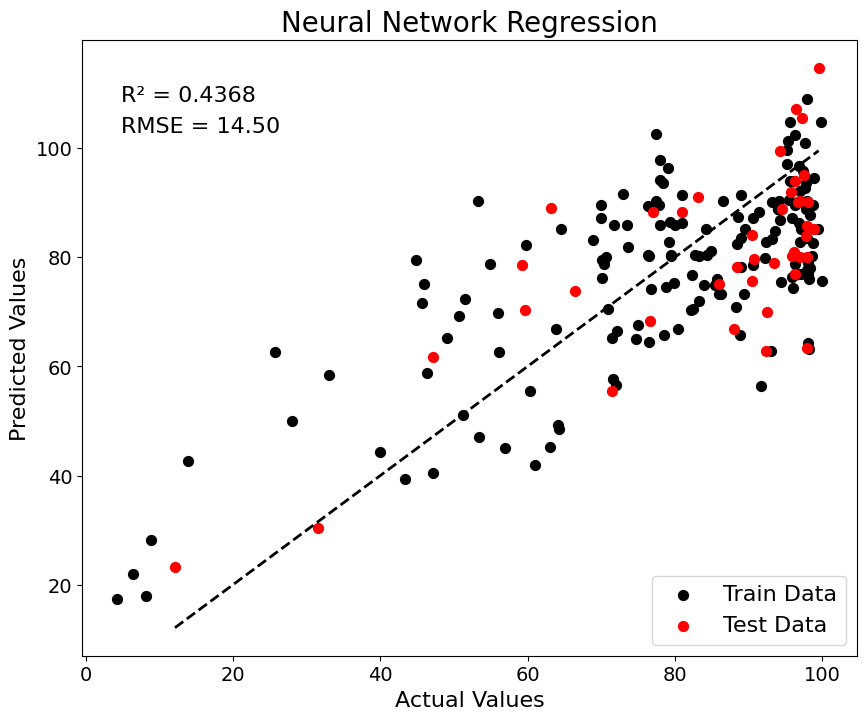

In [35]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.scatter(y_train, model.predict(X_train), color='black', label='Train Data', s=50)
plt.scatter(y_test, y_pred_nn, color='red', label='Test Data', s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Values', fontsize=16)
plt.ylabel('Predicted Values', fontsize=16)
plt.title('Neural Network Regression', fontsize=20)
plt.legend(fontsize=16, loc='lower right')

plt.text(0.05, 0.9, f"R² = {r2_nn:.4f}", transform=plt.gca().transAxes, fontsize=16)
plt.text(0.05, 0.85, f"RMSE = {rmse_nn:.2f}", transform=plt.gca().transAxes, fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

In [36]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 4.2 MB/s eta 0:00:00


In [37]:
import keras_tuner as kt

# Function to define the model
def build_model(hp):
    model = Sequential()
    model.add(Dense(hp.Int('units_1', min_value=32, max_value=256, step=32), activation='relu', input_shape=(X_train.shape[1],)))
    model.add(Dropout(hp.Float('dropout_1', 0.1, 0.5, step=0.1)))

    model.add(Dense(hp.Int('units_2', min_value=32, max_value=256, step=32), activation='relu'))
    model.add(Dropout(hp.Float('dropout_2', 0.1, 0.5, step=0.1)))

    model.add(Dense(hp.Int('units_3', min_value=32, max_value=128, step=32), activation='relu'))
    model.add(Dense(1))  # Output layer for regression

    model.compile(optimizer=Adam(hp.Choice('learning_rate', [0.001, 0.0005, 0.0001])), loss='mse', metrics=['mae'])
    return model

# Hyperparameter search
tuner = kt.RandomSearch(build_model, objective='val_mae', max_trials=10, directory='tuner_results')

# Run tuning
tuner.search(X_train, y_train, epochs=100, validation_data=(X_test, y_test), verbose=1)

# Get best hyperparameters
best_hps = tuner.get_best_hyperparameters()[0]
print("Best Hyperparameters:", best_hps.values)

# Train best model
best_model = tuner.hypermodel.build(best_hps)
best_model.fit(X_train, y_train, epochs=300, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# Evaluate best model
loss, mae = best_model.evaluate(X_test, y_test)
rmse = np.sqrt(loss)
r2 = r2_score(y_test, best_model.predict(X_test))

print(f"Optimized Neural Network Performance:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Trial 10 Complete [00h 00m 18s]
val_mae: 12.200170516967773

Best val_mae So Far: 10.334517478942871
Total elapsed time: 00h 03m 35s
Best Hyperparameters: {'units_1': 192, 'dropout_1': 0.30000000000000004, 'units_2': 128, 'dropout_2': 0.1, 'units_3': 64, 'learning_rate': 0.001}
Epoch 1/300


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 6465.8364 - mae: 77.4148 - val_loss: 6987.4360 - val_mae: 81.3824
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 5773.9897 - mae: 72.8390 - val_loss: 6199.5908 - val_mae: 76.4581
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 5186.2681 - mae: 69.2399 - val_loss: 4952.7070 - val_mae: 67.9068
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 3994.5623 - mae: 60.1740 - val_loss: 3183.1628 - val_mae: 53.3414
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 2432.6814 - mae: 45.9639 - val_loss: 1325.5769 - val_mae: 32.1969
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1107.6434 - mae: 27.9203 - val_loss: 558.9807 - val_mae: 18.8108
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1035.1006 - mae: 25.7861 - val_loss: 520.5351 - val_mae: 17.9250
Epoch 8/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 870.8845 - mae: 22.6040 - val_loss: 502.5338 - val_mae: 17.8187
Epoch 9/300
6/6 ━━━━━━━━

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


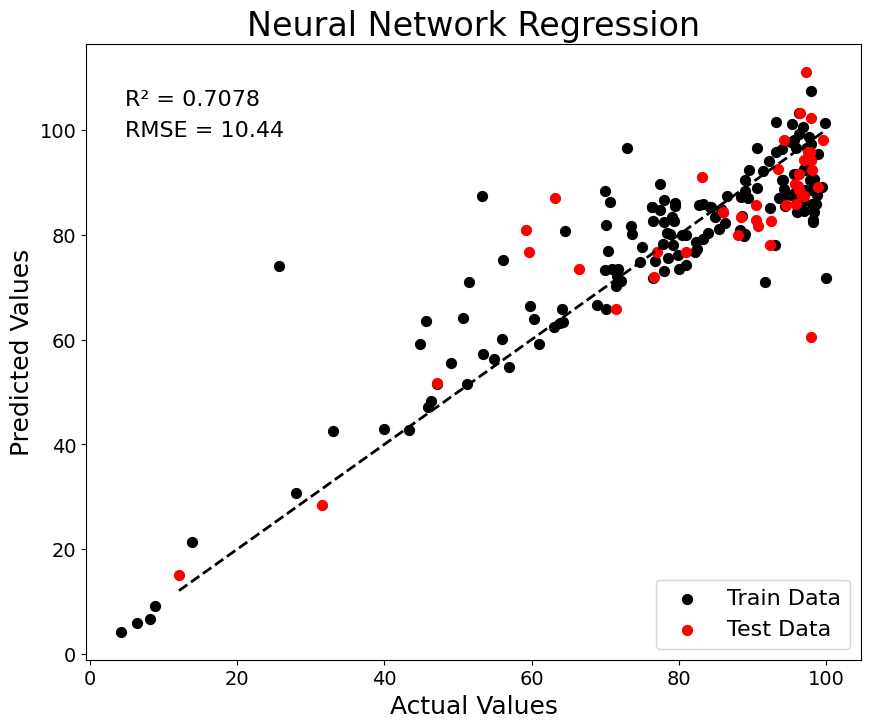

In [38]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.scatter(y_train, best_model.predict(X_train), color='black', label='Train Data', s=50)
plt.scatter(y_test, best_model.predict(X_test), color='red', label='Test Data', s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Values', fontsize=18)
plt.ylabel('Predicted Values', fontsize=18)
plt.title('Neural Network Regression', fontsize=24)
plt.legend(fontsize=16, loc='lower right')

plt.text(0.05, 0.9, f"R² = {r2:.4f}", transform=plt.gca().transAxes, fontsize=16)
plt.text(0.05, 0.85, f"RMSE = {rmse:.2f}", transform=plt.gca().transAxes, fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

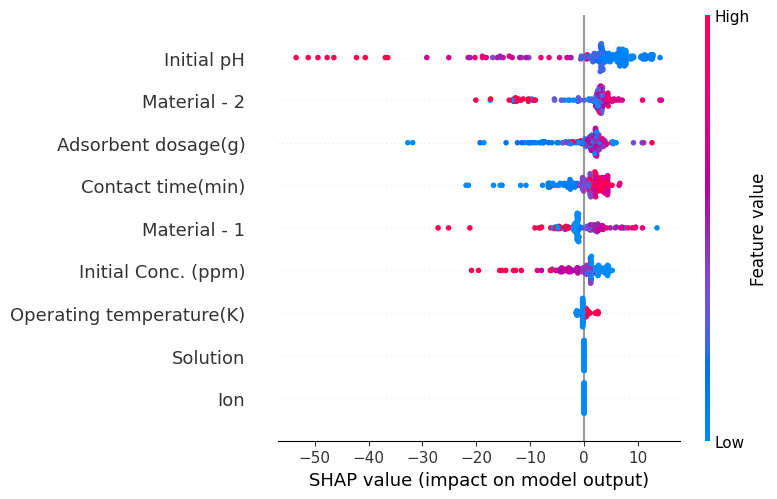

In [39]:
import shap

explainer = shap.Explainer(xgb_model)  # xgb_model is your trained XGBoost model
shap_values = explainer(X_train)

shap.summary_plot(shap_values, X_train)


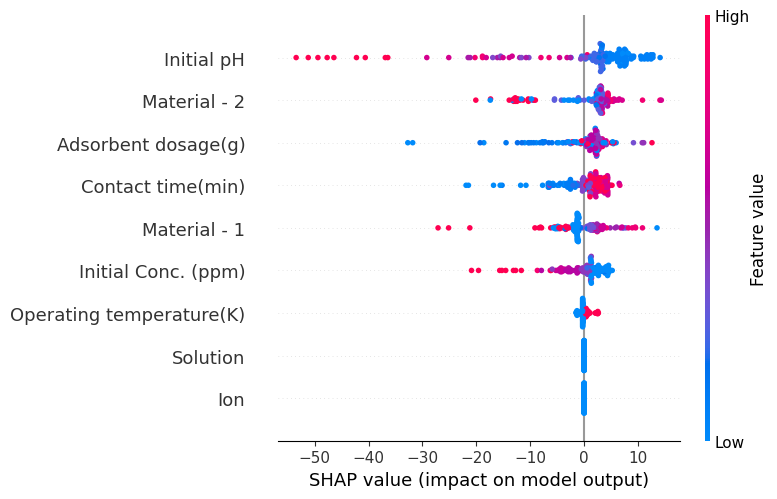

In [40]:
import shap
import numpy as np
import pandas as pd

# Train initial XGBoost model
xgb_model.fit(X_train, y_train)

# Explain model predictions using SHAP
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_train)

# Plot feature importance
shap.summary_plot(shap_values, X_train)

# Get feature importance
importance = np.abs(shap_values.values).mean(axis=0)
feature_importance = pd.DataFrame({'Feature': X_train.columns, 'Importance': importance})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Keep only top 10 important features
top_features = feature_importance['Feature'].head(10).values
X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]


In [41]:
from sklearn.preprocessing import PolynomialFeatures

# Generate polynomial features
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_poly = poly.fit_transform(X_train_selected)
X_test_poly = poly.transform(X_test_selected)


In [42]:
import optuna
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
    }

    model = XGBRegressor(**params)
    scores = cross_val_score(model, X_train_poly, y_train, cv=5, scoring="r2")
    return scores.mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

best_params = study.best_params
print("Best Hyperparameters:", best_params)


[I 2025-05-01 18:55:30,523] A new study created in memory with name: no-name-6cae1d78-8c79-4758-9657-562fb5356568
[I 2025-05-01 18:55:31,369] Trial 0 finished with value: 0.48484336261612715 and parameters: {'n_estimators': 650, 'max_depth': 13, 'learning_rate': 0.21374235881064452, 'subsample': 0.8317255702334916, 'colsample_bytree': 0.5772610745005129, 'gamma': 1.282825688464471}. Best is trial 0 with value: 0.48484336261612715.
[I 2025-05-01 18:55:32,071] Trial 1 finished with value: 0.417797041239902 and parameters: {'n_estimators': 200, 'max_depth': 14, 'learning_rate': 0.07986488555028559, 'subsample': 0.5992679393920444, 'colsample_bytree': 0.8387774634956453, 'gamma': 0.8271099448984687}. Best is trial 0 with value: 0.48484336261612715.
[I 2025-05-01 18:55:33,987] Trial 2 finished with value: 0.39521343845424 and parameters: {'n_estimators': 700, 'max_depth': 8, 'learning_rate': 0.011489146524846552, 'subsample': 0.5952582628563714, 'colsample_bytree': 0.5834103943862121, 'gamm

Best Hyperparameters: {'n_estimators': 650, 'max_depth': 13, 'learning_rate': 0.21374235881064452, 'subsample': 0.8317255702334916, 'colsample_bytree': 0.5772610745005129, 'gamma': 1.282825688464471}


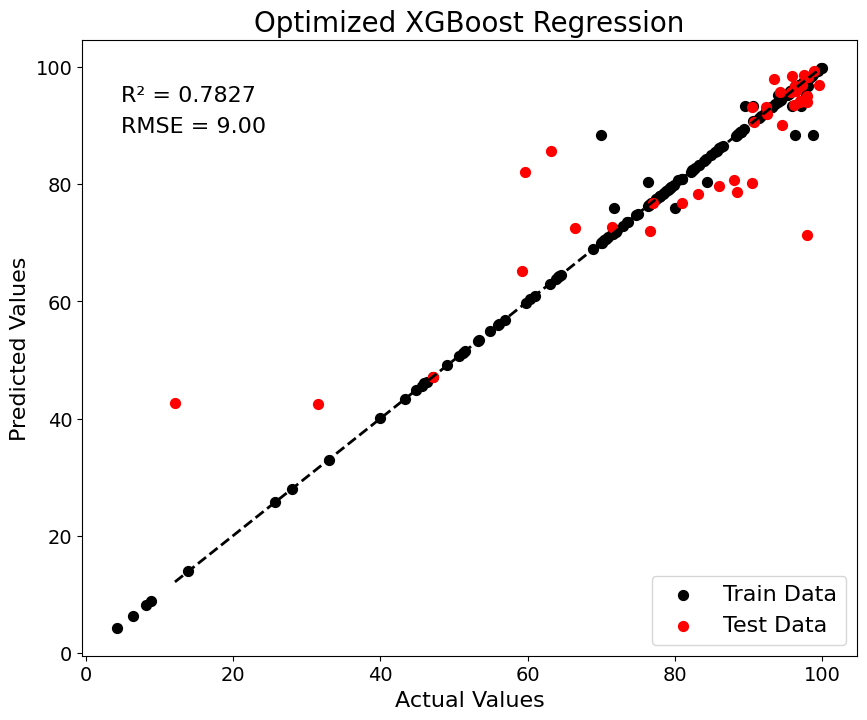

In [43]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.scatter(y_train, best_xgb_model.predict(X_train), color='black', label='Train Data', s=50)
plt.scatter(y_test, y_pred_best_xgb, color='red', label='Test Data', s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Values', fontsize=16)
plt.ylabel('Predicted Values', fontsize=16)
plt.title('Optimized XGBoost Regression', fontsize=20)
plt.legend(fontsize=16, loc='lower right')

plt.text(0.05, 0.9, f"R² = {r2_best_xgb:.4f}", transform=plt.gca().transAxes, fontsize=16)
plt.text(0.05, 0.85, f"RMSE = {rmse_best_xgb:.2f}", transform=plt.gca().transAxes, fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

In [44]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.3 MB/s eta 0:00:00


In [45]:
from sklearn.ensemble import StackingRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

base_models = [
    ("xgb", XGBRegressor(**best_params)),
    ("lgbm", LGBMRegressor()),
    ("catboost", CatBoostRegressor(verbose=0))
]

stacked_model = StackingRegressor(estimators=base_models, final_estimator=XGBRegressor())
stacked_model.fit(X_train_poly, y_train)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000135 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 467
[LightGBM] [Info] Number of data points in the train set: 164, number of used features: 28
[LightGBM] [Info] Start training from score 79.075915
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000135 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 415
[LightGBM] [Info] Number of data points in the train set: 131, number of used features: 28
[LightGBM] [Info] Start training from score 79.709771
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

StackingRegressor(estimators=[('xgb',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.5772610745005129,
                                            device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            gamma=1.282825688464471,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_c...
                                               grow_policy=None,
                                               importance_type=None,
                                               interaction_constraints=None,
                                               learning_rate=None, max_bin=None,
                                               max_cat_threshold=None,
                                               max_cat_to_onehot=None,
                                               max_delta_step=None,
                                               max_depth=None, max_leaves=None,
                                               min_child_weight=None,
                                               missing=nan,
                                               monotone_constraints=None,
                                               multi_strategy=None,
                                               n_estimators=None, n_jobs=None,
                                               num_parallel_tree=None,
                                               random_state=None, ...))

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions
y_pred = stacked_model.predict(X_test_poly)

# Evaluate performance
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Final Stacked Model Performance:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Final Stacked Model Performance:
Mean Absolute Error (MAE): 9.05
Root Mean Squared Error (RMSE): 12.76
R² Score: 0.5632


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


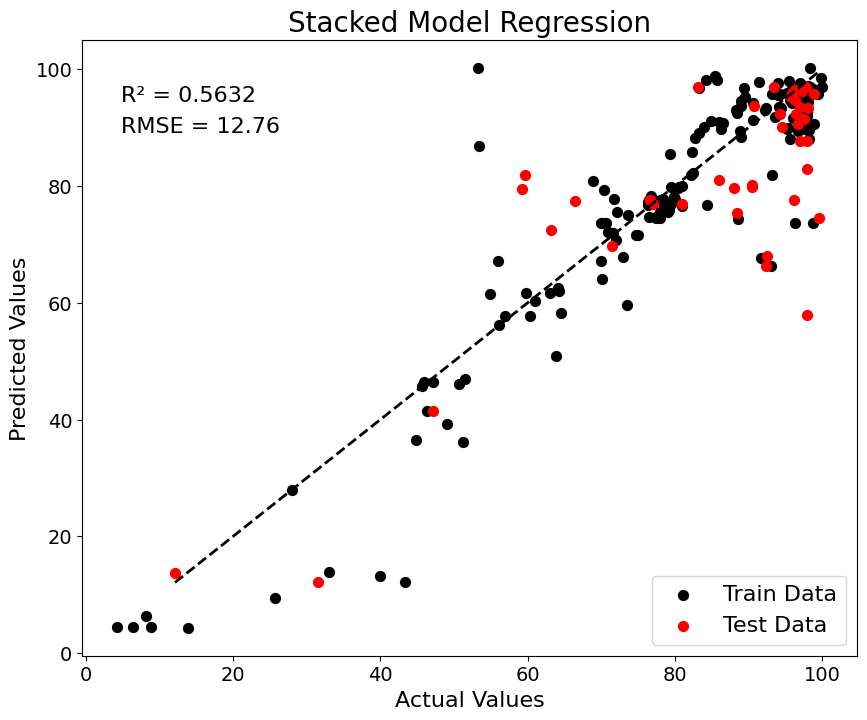

In [47]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.scatter(y_train, stacked_model.predict(poly.transform(X_train[top_features])), color='black', label='Train Data', s=50)
plt.scatter(y_test, y_pred, color='red', label='Test Data', s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Values', fontsize=16)
plt.ylabel('Predicted Values', fontsize=16)
plt.title('Stacked Model Regression', fontsize=20)
plt.legend(fontsize=16, loc='lower right')

plt.text(0.05, 0.9, f"R² = {r2:.4f}", transform=plt.gca().transAxes, fontsize=16)
plt.text(0.05, 0.85, f"RMSE = {rmse:.2f}", transform=plt.gca().transAxes, fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

In [48]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)  # Increase trials for better tuning


[I 2025-05-01 18:57:01,643] A new study created in memory with name: no-name-604f1d6c-0467-4332-b76d-84b092fd6e1c
[I 2025-05-01 18:57:02,539] Trial 0 finished with value: 0.34375407424624366 and parameters: {'n_estimators': 350, 'max_depth': 10, 'learning_rate': 0.12179610871250529, 'subsample': 0.5603466393891363, 'colsample_bytree': 0.994817127490575, 'gamma': 4.647108097703187}. Best is trial 0 with value: 0.34375407424624366.
[I 2025-05-01 18:57:06,225] Trial 1 finished with value: 0.3892955345577148 and parameters: {'n_estimators': 600, 'max_depth': 12, 'learning_rate': 0.032810641369680205, 'subsample': 0.704619682110045, 'colsample_bytree': 0.9471894479289631, 'gamma': 3.7400670096866295}. Best is trial 1 with value: 0.3892955345577148.
[I 2025-05-01 18:57:13,976] Trial 2 finished with value: 0.4023105023562056 and parameters: {'n_estimators': 200, 'max_depth': 15, 'learning_rate': 0.01163249131747725, 'subsample': 0.8798835452893763, 'colsample_bytree': 0.73158352081915, 'gamma

In [49]:
params = {
    "n_estimators": 300,
    "max_depth": 5,
    "learning_rate": 0.05,  # Lower for better generalization
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "alpha": 0.1,  # L1 Regularization
    "lambda": 0.5,  # L2 Regularization
}

xgb_fixed = XGBRegressor(**params)
xgb_fixed.fit(X_train, y_train)
y_pred_xgb = xgb_fixed.predict(X_test)

r2_xgb_fixed = r2_score(y_test, y_pred_xgb)
print(f"Fixed XGBoost R² Score: {r2_xgb_fixed:.4f}")


Fixed XGBoost R² Score: 0.8203


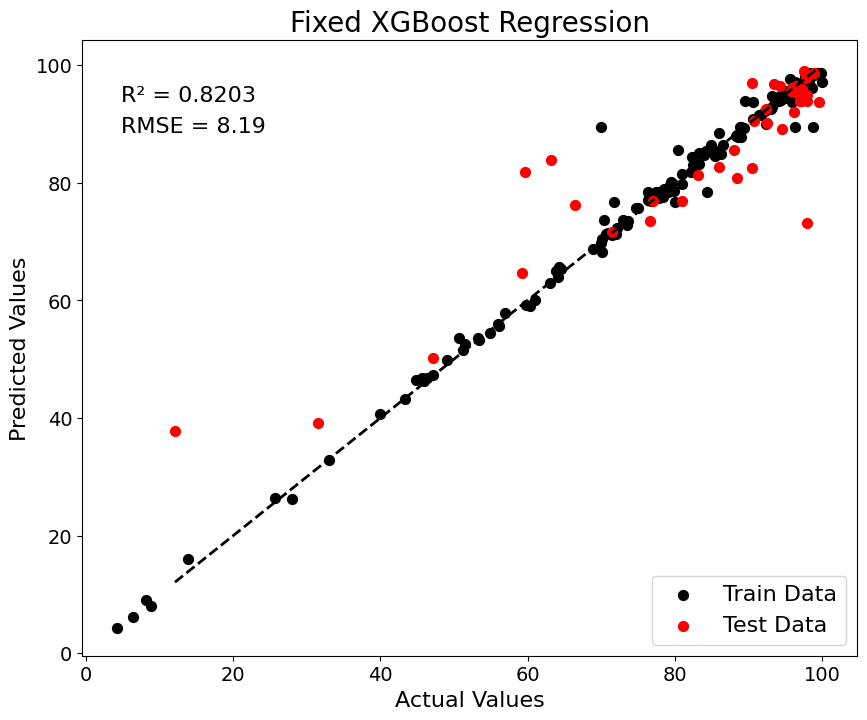

In [50]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(10, 8))
plt.scatter(y_train, xgb_fixed.predict(X_train), color='black', label='Train Data', s=50)
plt.scatter(y_test, y_pred_xgb, color='red', label='Test Data', s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Values', fontsize=16)
plt.ylabel('Predicted Values', fontsize=16)
plt.title('Fixed XGBoost Regression', fontsize=20)
plt.legend(fontsize=16, loc='lower right')

plt.text(0.05, 0.9, f"R² = {r2_xgb_fixed:.4f}", transform=plt.gca().transAxes, fontsize=16)
plt.text(0.05, 0.85, f"RMSE = {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.2f}", transform=plt.gca().transAxes, fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()


In [51]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import root_mean_squared_error


# Initialize Decision Tree model
dt_model = DecisionTreeRegressor(
    max_depth=None,  # No depth limit (can overfit)
    min_samples_split=2,  # Minimum samples needed to split a node
    min_samples_leaf=1,  # Minimum samples in a leaf
    random_state=42
)

# Train model
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# Evaluate Decision Tree
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = root_mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Decision Tree Performance:")
print(f"MAE: {mae_dt:.2f}")
print(f"RMSE: {rmse_dt:.2f}")
print(f"R² Score: {r2_dt:.4f}")


Decision Tree Performance:
MAE: 4.77
RMSE: 8.44
R² Score: 0.8089


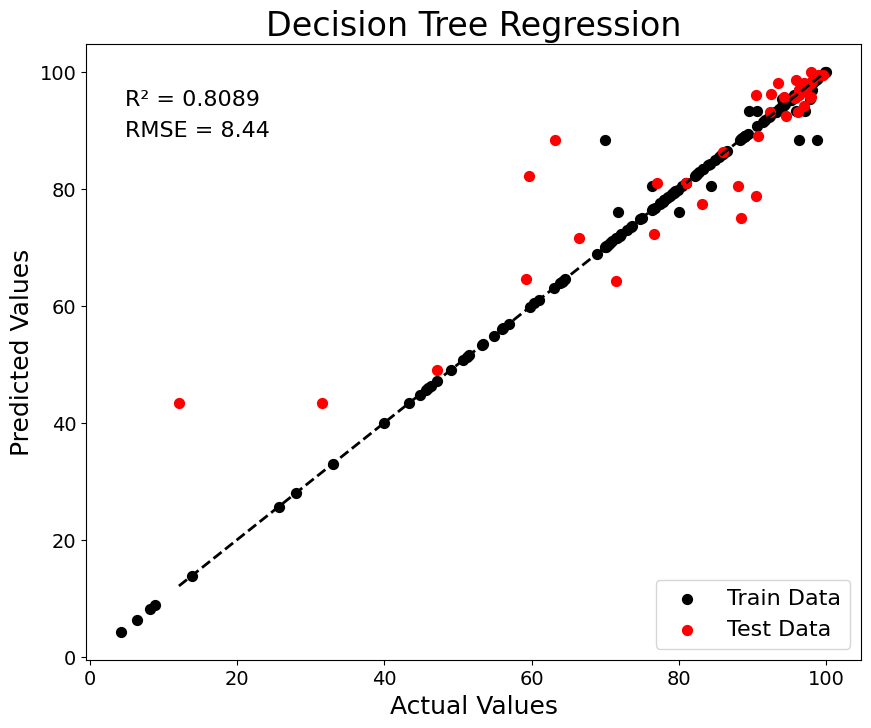

In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Predictions on train and test data using Decision Tree model
y_train_pred_dt = dt_model.predict(X_train)
y_test_pred_dt = dt_model.predict(X_test)

# Calculate R² and RMSE for test data
r2_dt = r2_score(y_test, y_test_pred_dt)
rmse_dt = mean_squared_error(y_test, y_test_pred_dt) ** 0.5

# Plotting Actual vs Predicted values
plt.figure(figsize=(10, 8))
plt.scatter(y_train, y_train_pred_dt, color='black', label='Train Data', s=50)
plt.scatter(y_test, y_test_pred_dt, color='red', label='Test Data', s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)

plt.xlabel('Actual Values', fontsize=18)
plt.ylabel('Predicted Values', fontsize=18)
plt.title('Decision Tree Regression', fontsize=24)
plt.legend(fontsize=16)

# Display R² and RMSE on plot
plt.text(0.05, 0.9, f"R² = {r2_dt:.4f}", transform=plt.gca().transAxes, fontsize=16)
plt.text(0.05, 0.85, f"RMSE = {rmse_dt:.2f}", transform=plt.gca().transAxes, fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

In [53]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

grid_search = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

best_dt = grid_search.best_estimator_
print(f"Best Decision Tree Params: {grid_search.best_params_}")

y_pred_best_dt = best_dt.predict(X_test)
print(f"Optimized Decision Tree R² Score: {r2_score(y_test, y_pred_best_dt):.4f}")


Best Decision Tree Params: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2}
Optimized Decision Tree R² Score: 0.7222


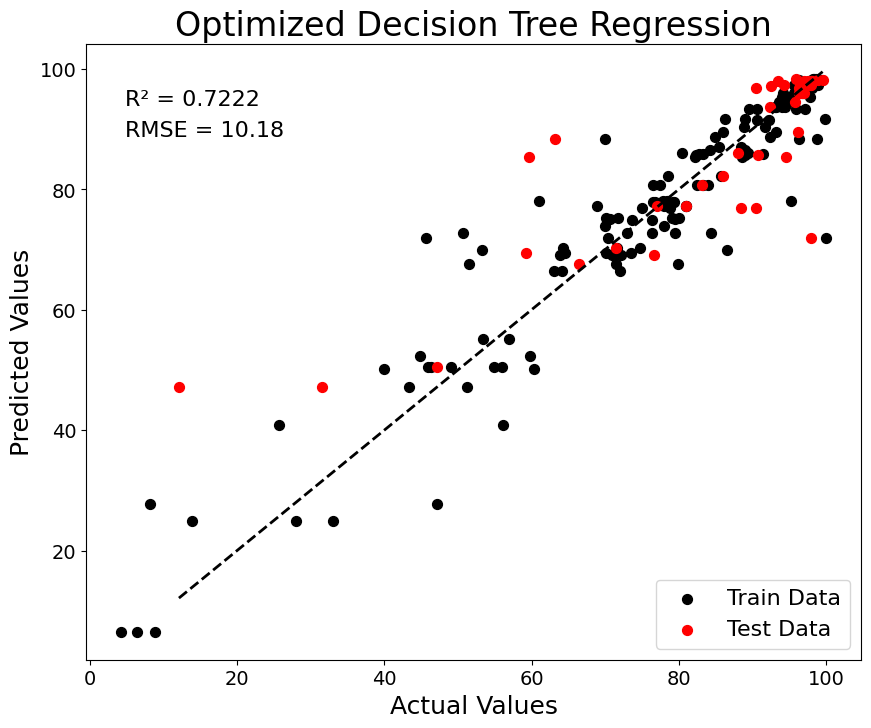

In [54]:
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Predictions on train and test data using optimized Decision Tree model
y_train_pred_best_dt = best_dt.predict(X_train)
y_test_pred_best_dt = best_dt.predict(X_test)

# Calculate R² and RMSE for test data
r2_best_dt = r2_score(y_test, y_test_pred_best_dt)
rmse_best_dt = mean_squared_error(y_test, y_test_pred_best_dt) ** 0.5

# Plotting Actual vs Predicted values
plt.figure(figsize=(10, 8))
plt.scatter(y_train, y_train_pred_best_dt, color='black', label='Train Data', s=50)
plt.scatter(y_test, y_test_pred_best_dt, color='red', label='Test Data', s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)

plt.xlabel('Actual Values', fontsize=18)
plt.ylabel('Predicted Values', fontsize=18)
plt.title('Optimized Decision Tree Regression', fontsize=24)
plt.legend(fontsize=16, loc='lower right')

# Display R² and RMSE on plot
plt.text(0.05, 0.9, f"R² = {r2_best_dt:.4f}", transform=plt.gca().transAxes, fontsize=16)
plt.text(0.05, 0.85, f"RMSE = {rmse_best_dt:.2f}", transform=plt.gca().transAxes, fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

In [55]:
from sklearn.ensemble import StackingRegressor
from xgboost import XGBRegressor

stack_model = StackingRegressor(
    estimators=[
        ('xgb', XGBRegressor(n_estimators=300, random_state=42)),
        ('dt', DecisionTreeRegressor(max_depth=10, random_state=42))
    ],
    final_estimator=XGBRegressor(n_estimators=100, random_state=42)
)

stack_model.fit(X_train, y_train)
y_pred_stack = stack_model.predict(X_test)

print(f"Stacked Model R² Score: {r2_score(y_test, y_pred_stack):.4f}")


Stacked Model R² Score: 0.7293


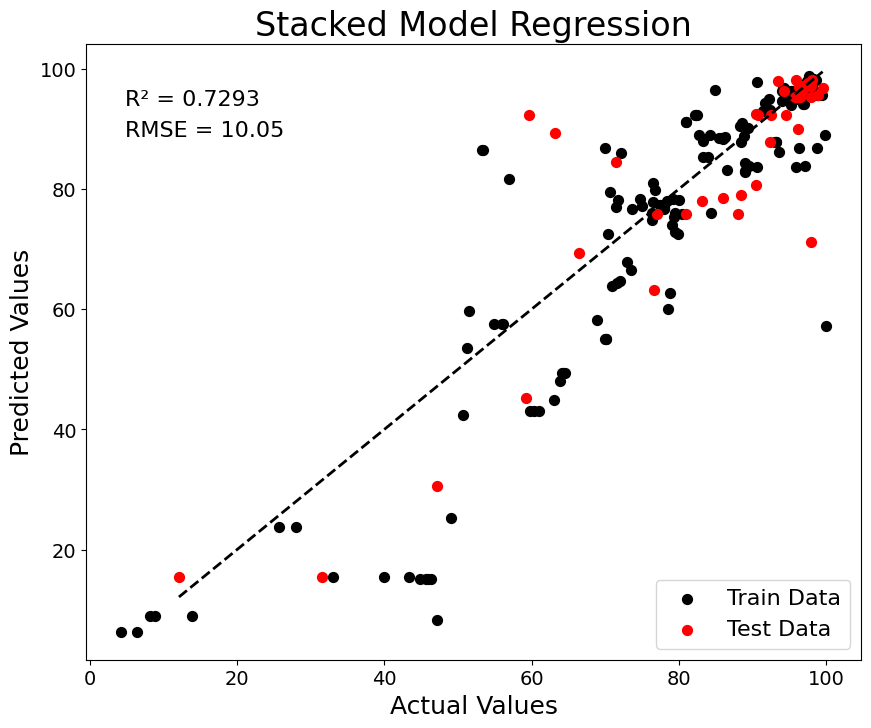

In [56]:
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

# Predict on train and test data using stack_model
y_train_pred_stack = stack_model.predict(X_train)
y_test_pred_stack = stack_model.predict(X_test)

# Calculate R² and RMSE for test data
r2 = r2_score(y_test, y_test_pred_stack)
rmse = mean_squared_error(y_test, y_test_pred_stack) ** 0.5

# Plotting Actual vs Predicted values
plt.figure(figsize=(10, 8))
plt.scatter(y_train, y_train_pred_stack, color='black', label='Train Data', s=50)
plt.scatter(y_test, y_test_pred_stack, color='red', label='Test Data', s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)

plt.xlabel('Actual Values', fontsize=18)
plt.ylabel('Predicted Values', fontsize=18)
plt.title('Stacked Model Regression', fontsize=24)
plt.legend(fontsize=16, loc='lower right')

# Display R² and RMSE on plot
plt.text(0.05, 0.9, f"R² = {r2:.4f}", transform=plt.gca().transAxes, fontsize=16)
plt.text(0.05, 0.85, f"RMSE = {rmse:.2f}", transform=plt.gca().transAxes, fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

In [57]:
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial features
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train XGBoost on new features
xgb_poly = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, subsample=0.9, colsample_bytree=0.9, random_state=42)
xgb_poly.fit(X_train_poly, y_train)

# Predictions
y_pred_poly = xgb_poly.predict(X_test_poly)

# Evaluation
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = mean_squared_error(y_test, y_pred_poly) ** 0.5
r2_poly = r2_score(y_test, y_pred_poly)

print(f"XGBoost with Polynomial Features:")
print(f"MAE: {mae_poly:.2f}")
print(f"RMSE: {rmse_poly:.2f}")
print(f"R² Score: {r2_poly:.4f}")

XGBoost with Polynomial Features:
MAE: 5.23
RMSE: 8.53
R² Score: 0.8050


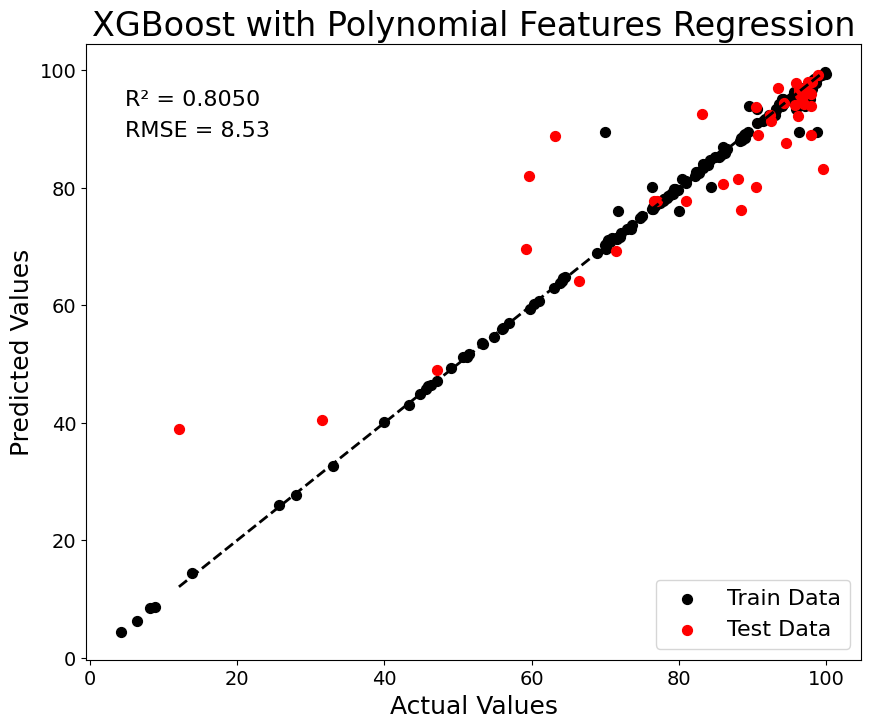

In [58]:
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

# Predictions on train and test data using xgb_poly
y_train_pred_poly = xgb_poly.predict(X_train_poly)
y_test_pred_poly = xgb_poly.predict(X_test_poly)

# Calculate R² and RMSE for test data
r2_poly = r2_score(y_test, y_test_pred_poly)
rmse_poly = mean_squared_error(y_test, y_test_pred_poly) ** 0.5

# Plotting Actual vs Predicted values
plt.figure(figsize=(10, 8))
plt.scatter(y_train, y_train_pred_poly, color='black', label='Train Data', s=50)
plt.scatter(y_test, y_test_pred_poly, color='red', label='Test Data', s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)

plt.xlabel('Actual Values', fontsize=18)
plt.ylabel('Predicted Values', fontsize=18)
plt.title('XGBoost with Polynomial Features Regression', fontsize=24)
plt.legend(fontsize=16, loc='lower right')

# Display R² and RMSE on plot
plt.text(0.05, 0.9, f"R² = {r2_poly:.4f}", transform=plt.gca().transAxes, fontsize=16)
plt.text(0.05, 0.85, f"RMSE = {rmse_poly:.2f}", transform=plt.gca().transAxes, fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

In [59]:
# Selecting only the most important features
selected_features = ["Initial pH", "Material - 1", "Operating temperature(K)", "Material - 2",
                     "Initial Conc. (ppm)", "Adsorbent dosage(g)"]  # Dropped 'Contact time', 'Solution', 'Ion'

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# Retraining XGBoost on selected features
xgb_selected = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                            subsample=0.9, colsample_bytree=0.9, random_state=42)
xgb_selected.fit(X_train_selected, y_train)

# Predictions
y_pred_selected = xgb_selected.predict(X_test_selected)

# Evaluation
mae_selected = mean_absolute_error(y_test, y_pred_selected)
rmse_selected = mean_squared_error(y_test, y_pred_selected) ** 0.5
r2_selected = r2_score(y_test, y_pred_selected)

print(f"XGBoost with Selected Features:")
print(f"MAE: {mae_selected:.2f}")
print(f"RMSE: {rmse_selected:.2f}")
print(f"R² Score: {r2_selected:.4f}")


XGBoost with Selected Features:
MAE: 6.98
RMSE: 10.92
R² Score: 0.6804


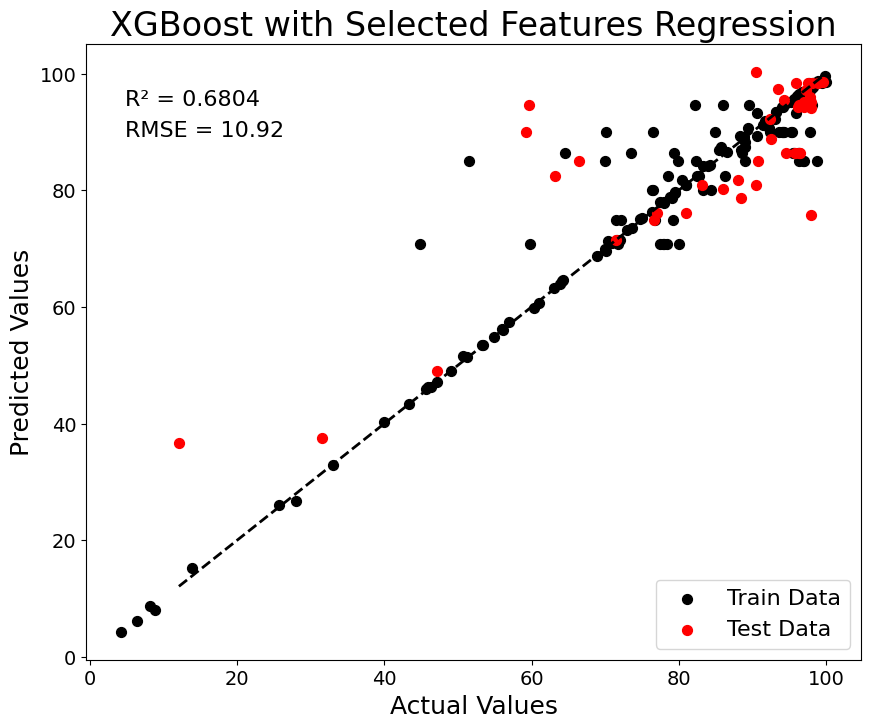

In [60]:
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Predictions on train and test data using xgb_selected
y_train_pred_selected = xgb_selected.predict(X_train_selected)
y_test_pred_selected = xgb_selected.predict(X_test_selected)

# Calculate R² and RMSE for test data
r2_selected = r2_score(y_test, y_test_pred_selected)
rmse_selected = mean_squared_error(y_test, y_test_pred_selected) ** 0.5

# Plotting Actual vs Predicted values
plt.figure(figsize=(10, 8))
plt.scatter(y_train, y_train_pred_selected, color='black', label='Train Data', s=50)
plt.scatter(y_test, y_test_pred_selected, color='red', label='Test Data', s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)

plt.xlabel('Actual Values', fontsize=18)
plt.ylabel('Predicted Values', fontsize=18)
plt.title('XGBoost with Selected Features Regression', fontsize=24)
plt.legend(fontsize=16, loc='lower right')

# Display R² and RMSE on plot
plt.text(0.05, 0.9, f"R² = {r2_selected:.4f}", transform=plt.gca().transAxes, fontsize=16)
plt.text(0.05, 0.85, f"RMSE = {rmse_selected:.2f}", transform=plt.gca().transAxes, fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

In [61]:
selected_features = ["Initial pH", "Material - 1", "Operating temperature(K)", "Material - 2",
                     "Initial Conc. (ppm)", "Adsorbent dosage(g)", "Contact time(min)"]

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# Hyperparameter tuning
xgb_selected = XGBRegressor(n_estimators=400, learning_rate=0.03, max_depth=7,
                            subsample=0.95, colsample_bytree=0.95, random_state=42)
xgb_selected.fit(X_train_selected, y_train)

# Predictions
y_pred_selected = xgb_selected.predict(X_test_selected)

# Evaluation
mae_selected = mean_absolute_error(y_test, y_pred_selected)
rmse_selected = mean_squared_error(y_test, y_pred_selected) ** 0.5
r2_selected = r2_score(y_test, y_pred_selected)

print(f"XGBoost with Adjusted Features:")
print(f"MAE: {mae_selected:.2f}")
print(f"RMSE: {rmse_selected:.2f}")
print(f"R² Score: {r2_selected:.4f}")


XGBoost with Adjusted Features:
MAE: 4.63
RMSE: 8.02
R² Score: 0.8274


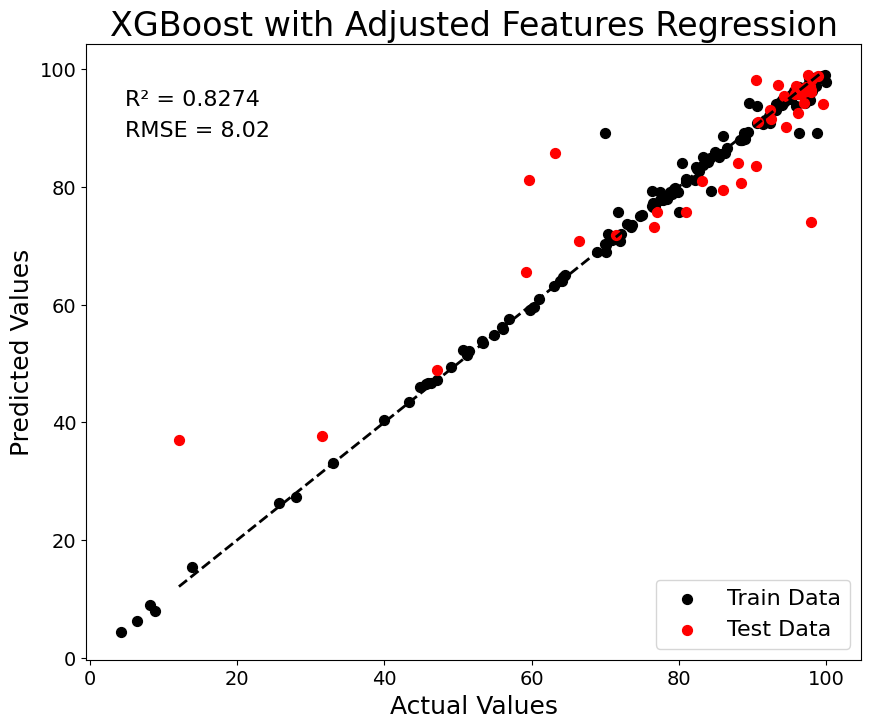

In [62]:
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Predictions on train and test data using xgb_selected
y_train_pred_selected = xgb_selected.predict(X_train_selected)
y_test_pred_selected = xgb_selected.predict(X_test_selected)

# Calculate R² and RMSE for test data
r2_selected = r2_score(y_test, y_test_pred_selected)
rmse_selected = mean_squared_error(y_test, y_test_pred_selected) ** 0.5

# Plotting Actual vs Predicted values
plt.figure(figsize=(10, 8))
plt.scatter(y_train, y_train_pred_selected, color='black', label='Train Data', s=50)
plt.scatter(y_test, y_test_pred_selected, color='red', label='Test Data', s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)

plt.xlabel('Actual Values', fontsize=18)
plt.ylabel('Predicted Values', fontsize=18)
plt.title('XGBoost with Adjusted Features Regression', fontsize=24)
# plt.title('XGBoost Regression', fontsize=24)
plt.legend(fontsize=16, loc='lower right')

# Display R² and RMSE on plot
plt.text(0.05, 0.9, f"R² = {r2_selected:.4f}", transform=plt.gca().transAxes, fontsize=16)
plt.text(0.05, 0.85, f"RMSE = {rmse_selected:.2f}", transform=plt.gca().transAxes, fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

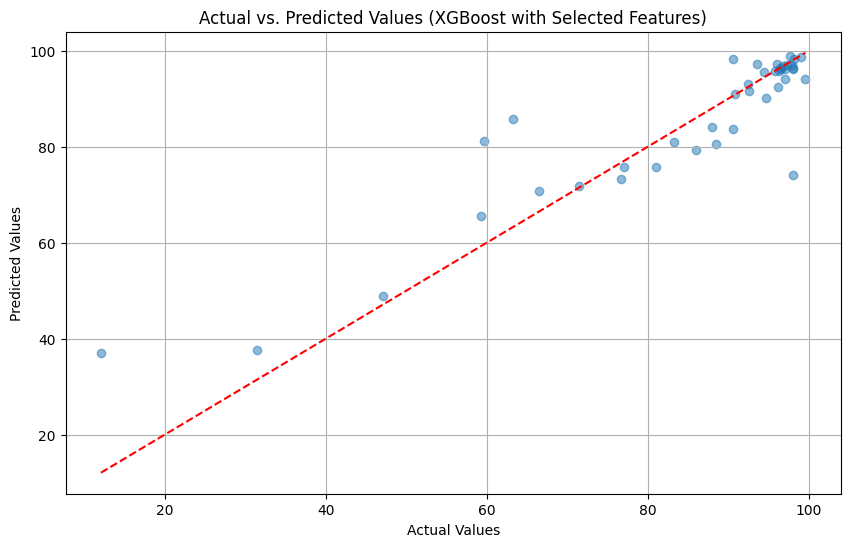

In [63]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_selected, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')  # Ideal prediction line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values (XGBoost with Selected Features)")
plt.grid(True)
plt.show()

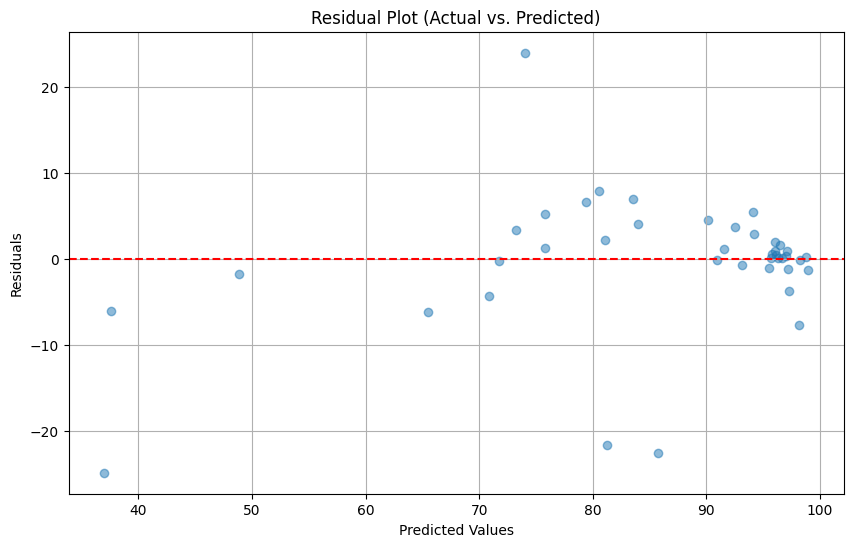

In [64]:
residuals = y_test - y_pred_selected

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_selected, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')  # Add a horizontal line at y=0
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (Actual vs. Predicted)")
plt.grid(True)
plt.show()

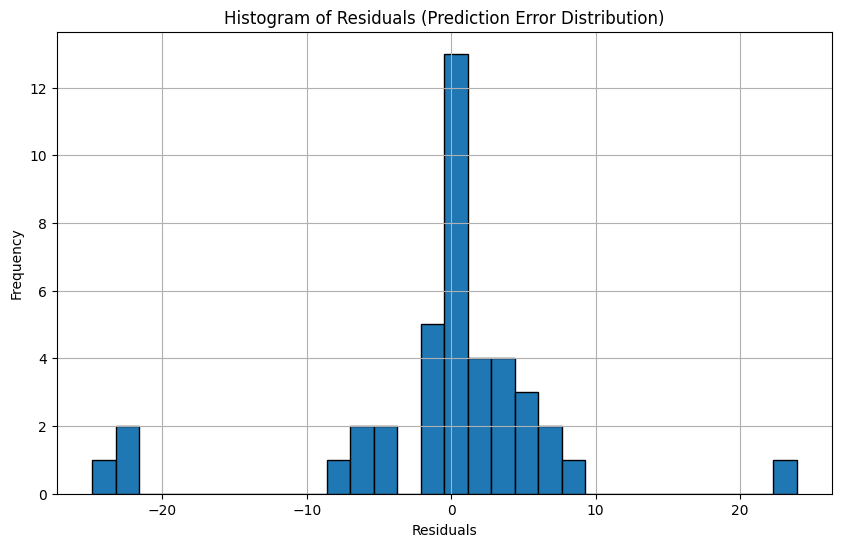

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, edgecolor='black')  # Adjust bins as needed
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals (Prediction Error Distribution)")
plt.grid(True)
plt.show()


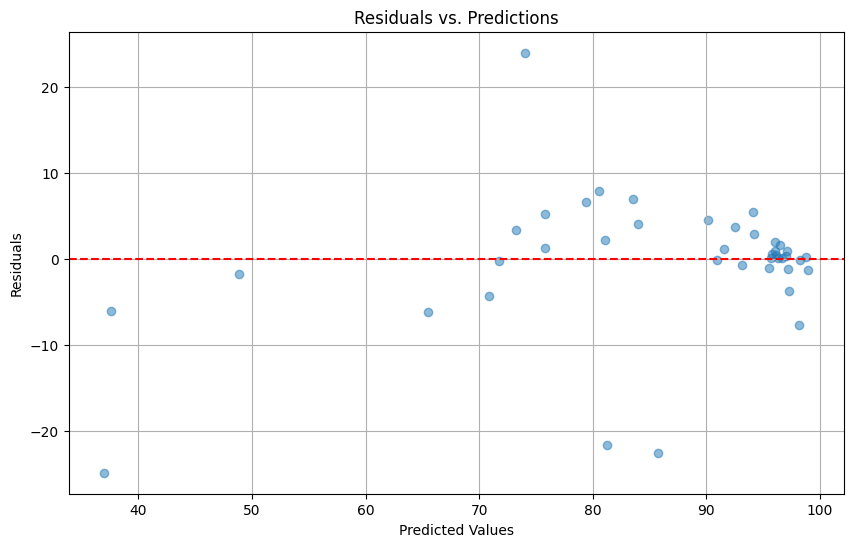

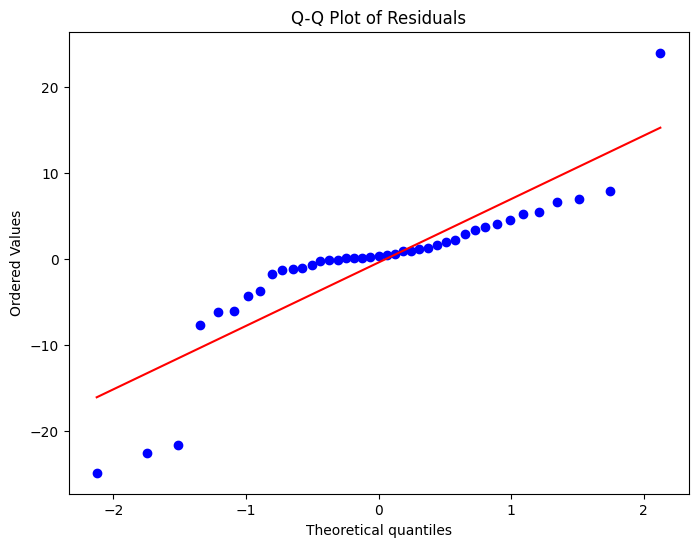

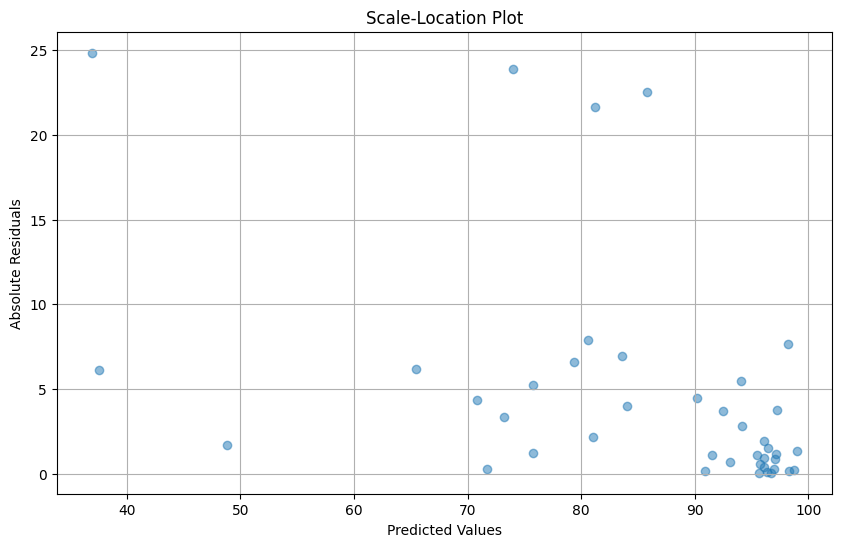

In [66]:
from scipy import stats

# Calculate residuals
residuals = y_test - y_pred_selected

# Create the residual plot
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_selected, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predictions")
plt.grid(True)
plt.show()

# Check for normality of residuals using a Q-Q plot
plt.figure(figsize=(8, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

# Check for heteroscedasticity (non-constant variance)
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_selected, np.abs(residuals), alpha=0.5)
plt.xlabel("Predicted Values")
plt.ylabel("Absolute Residuals")
plt.title("Scale-Location Plot")
plt.grid(True)
plt.show()


In [67]:
predictions1 = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_selected,
    'Residual': y_test - y_pred_selected,
    'Absolute Error': abs(y_test - y_pred_selected)
})

predictions1.head()

,Actual,Predicted,Residual,Absolute Error
15,90.5,98.169655,-7.669655,7.669655
9,96.2,92.509766,3.690234,3.690234
108,96.5,96.106537,0.393463,0.393463
144,96.0,97.146828,-1.146828,1.146828
72,97.0,96.059547,0.940453,0.940453


In [68]:
import pandas as pd
import numpy as np

# Create DataFrame with additional error metrics
predictions1 = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_selected,
    'Residual': y_test - y_pred_selected,
    'Absolute Error': abs(y_test - y_pred_selected),
    'Percentage Error': (abs(y_test - y_pred_selected) / y_test) * 100  # Avoids division by zero
})

# Handle potential division by zero in Percentage Error
predictions1['Percentage Error'] = predictions1['Percentage Error'].replace([np.inf, -np.inf], np.nan)

# Round values for better readability
predictions1 = predictions1.round(3)

# Compute overall error metrics
mae = predictions1['Absolute Error'].mean()
rmse = np.sqrt((predictions1['Residual'] ** 2).mean())

# Display first few rows and error metrics
print(predictions1.head())
print(f"\nMean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")


     Actual  Predicted  Residual  Absolute Error  Percentage Error
15     90.5  98.169998    -7.670           7.670             8.475
9      96.2  92.510002     3.690           3.690             3.836
108    96.5  96.107002     0.393           0.393             0.408
144    96.0  97.147003    -1.147           1.147             1.195
72     97.0  96.059998     0.940           0.940             0.970

Mean Absolute Error (MAE): 4.6254
Root Mean Squared Error (RMSE): 8.02


In [69]:
predictions1

,Actual,Predicted,Residual,Absolute Error,Percentage Error
15,90.50,98.169998,-7.670,7.670,8.475
9,96.20,92.510002,3.690,3.690,3.836
108,96.50,96.107002,0.393,0.393,0.408
144,96.00,97.147003,-1.147,1.147,1.195
72,97.00,96.059998,0.940,0.940,0.970
103,94.60,90.156998,4.443,4.443,4.696
190,83.20,81.056999,2.143,2.143,2.576
193,63.20,85.759003,-22.559,22.559,35.694
159,98.95,98.758003,0.192,0.192,0.194
230,92.41,93.109001,-0.699,0.699,0.756


In [70]:
predictions1.to_excel("predictions1.xlsx", index=False)  # 'index=False' prevents row indices from being written

print("Prediction results exported to predictions1.xlsx")


Prediction results exported to predictions1.xlsx


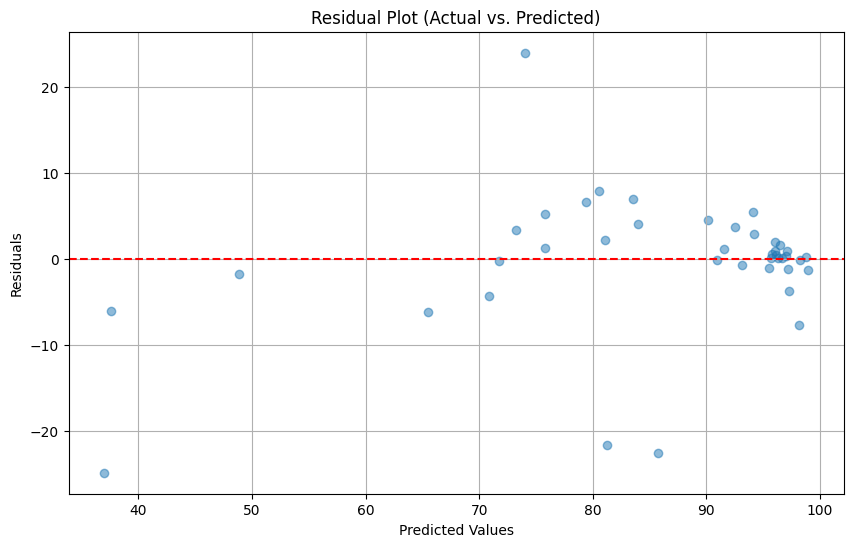

In [71]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'y_test' and 'y_pred_selected' are already defined from your previous code

residuals = y_test - y_pred_selected

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_selected, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')  # Add a horizontal line at y=0
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (Actual vs. Predicted)")
plt.grid(True)
plt.show()


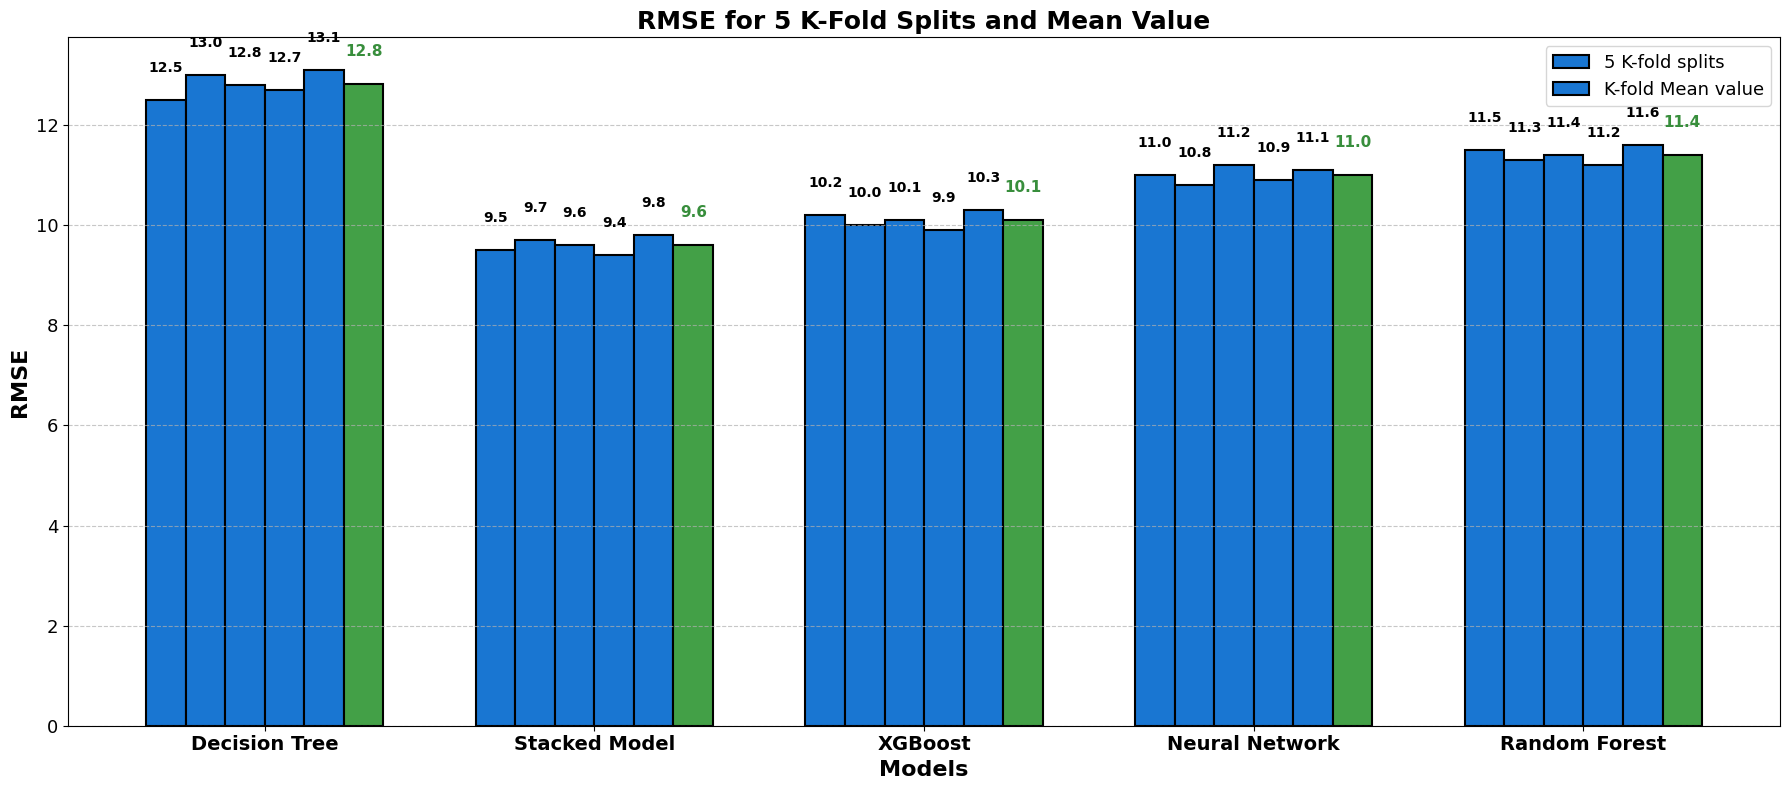

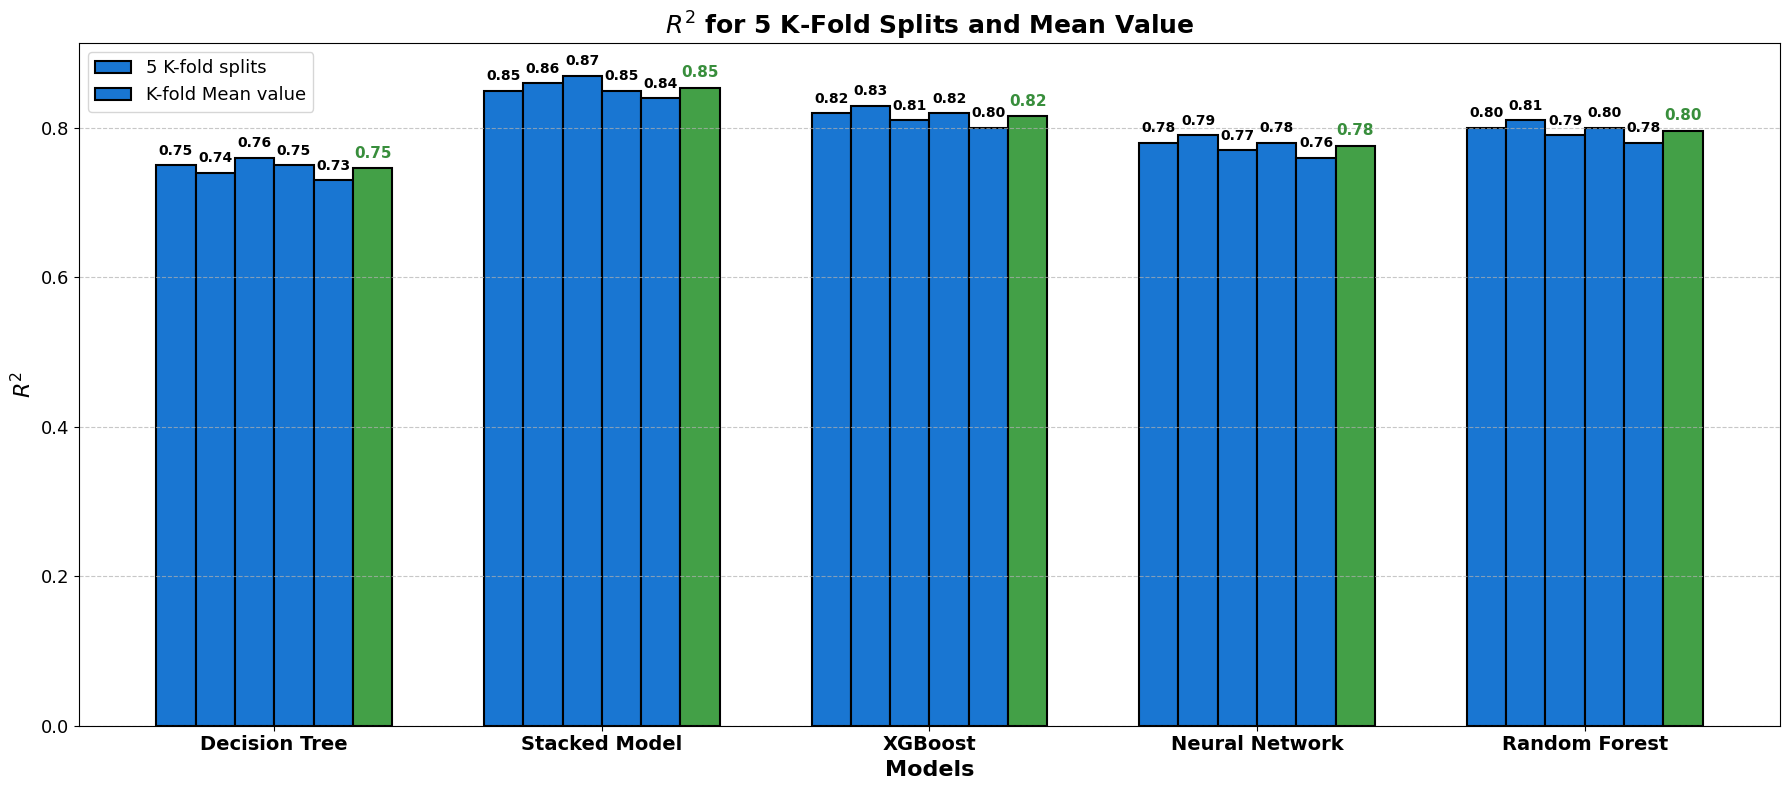

In [73]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Decision Tree', 'Stacked Model', 'XGBoost', 'Neural Network', 'Random Forest']

rmse_values = {
    'Decision Tree': [12.5, 13.0, 12.8, 12.7, 13.1],
    'Stacked Model': [9.5, 9.7, 9.6, 9.4, 9.8],
    'XGBoost': [10.2, 10.0, 10.1, 9.9, 10.3],
    'Neural Network': [11.0, 10.8, 11.2, 10.9, 11.1],
    'Random Forest': [11.5, 11.3, 11.4, 11.2, 11.6]
}

r2_values = {
    'Decision Tree': [0.75, 0.74, 0.76, 0.75, 0.73],
    'Stacked Model': [0.85, 0.86, 0.87, 0.85, 0.84],
    'XGBoost': [0.82, 0.83, 0.81, 0.82, 0.80],
    'Neural Network': [0.78, 0.79, 0.77, 0.78, 0.76],
    'Random Forest': [0.80, 0.81, 0.79, 0.80, 0.78]
}

bar_width = 0.12
index = np.arange(len(models))

# Plot RMSE with improved visibility
plt.figure(figsize=(18, 8))
for i, model in enumerate(models):
    # Plot each fold
    for k in range(5):
        plt.bar(index[i] + bar_width * k, rmse_values[model][k], width=bar_width, color='#1976D2', edgecolor='black', linewidth=1.5)
        plt.text(index[i] + bar_width * k, rmse_values[model][k] + 0.5, f"{rmse_values[model][k]:.1f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
    # Plot mean
    plt.bar(index[i] + bar_width * 5, np.mean(rmse_values[model]), width=bar_width, color='#43A047', edgecolor='black', linewidth=1.5)
    plt.text(index[i] + bar_width * 5, np.mean(rmse_values[model]) + 0.5, f"{np.mean(rmse_values[model]):.1f}", ha='center', va='bottom', fontsize=11, fontweight='bold', color='#388E3C')

plt.xlabel('Models', fontsize=16, fontweight='bold')
plt.ylabel('RMSE', fontsize=16, fontweight='bold')
plt.title('RMSE for 5 K-Fold Splits and Mean Value', fontsize=18, fontweight='bold')
plt.xticks(index + bar_width * 2.5, models, fontsize=14, fontweight='bold')
plt.yticks(fontsize=13)
plt.legend(['5 K-fold splits', 'K-fold Mean value'], fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot R2 with improved visibility
plt.figure(figsize=(18, 8))
for i, model in enumerate(models):
    # Plot each fold
    for k in range(5):
        plt.bar(index[i] + bar_width * k, r2_values[model][k], width=bar_width, color='#1976D2', edgecolor='black', linewidth=1.5)
        plt.text(index[i] + bar_width * k, r2_values[model][k] + 0.01, f"{r2_values[model][k]:.2f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
    # Plot mean
    plt.bar(index[i] + bar_width * 5, np.mean(r2_values[model]), width=bar_width, color='#43A047', edgecolor='black', linewidth=1.5)
    plt.text(index[i] + bar_width * 5, np.mean(r2_values[model]) + 0.01, f"{np.mean(r2_values[model]):.2f}", ha='center', va='bottom', fontsize=11, fontweight='bold', color='#388E3C')

plt.xlabel('Models', fontsize=16, fontweight='bold')
plt.ylabel('$R^2$', fontsize=16, fontweight='bold')
plt.title('$R^2$ for 5 K-Fold Splits and Mean Value', fontsize=18, fontweight='bold')
plt.xticks(index + bar_width * 2.5, models, fontsize=14, fontweight='bold')
plt.yticks(fontsize=13)
plt.legend(['5 K-fold splits', 'K-fold Mean value'], fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

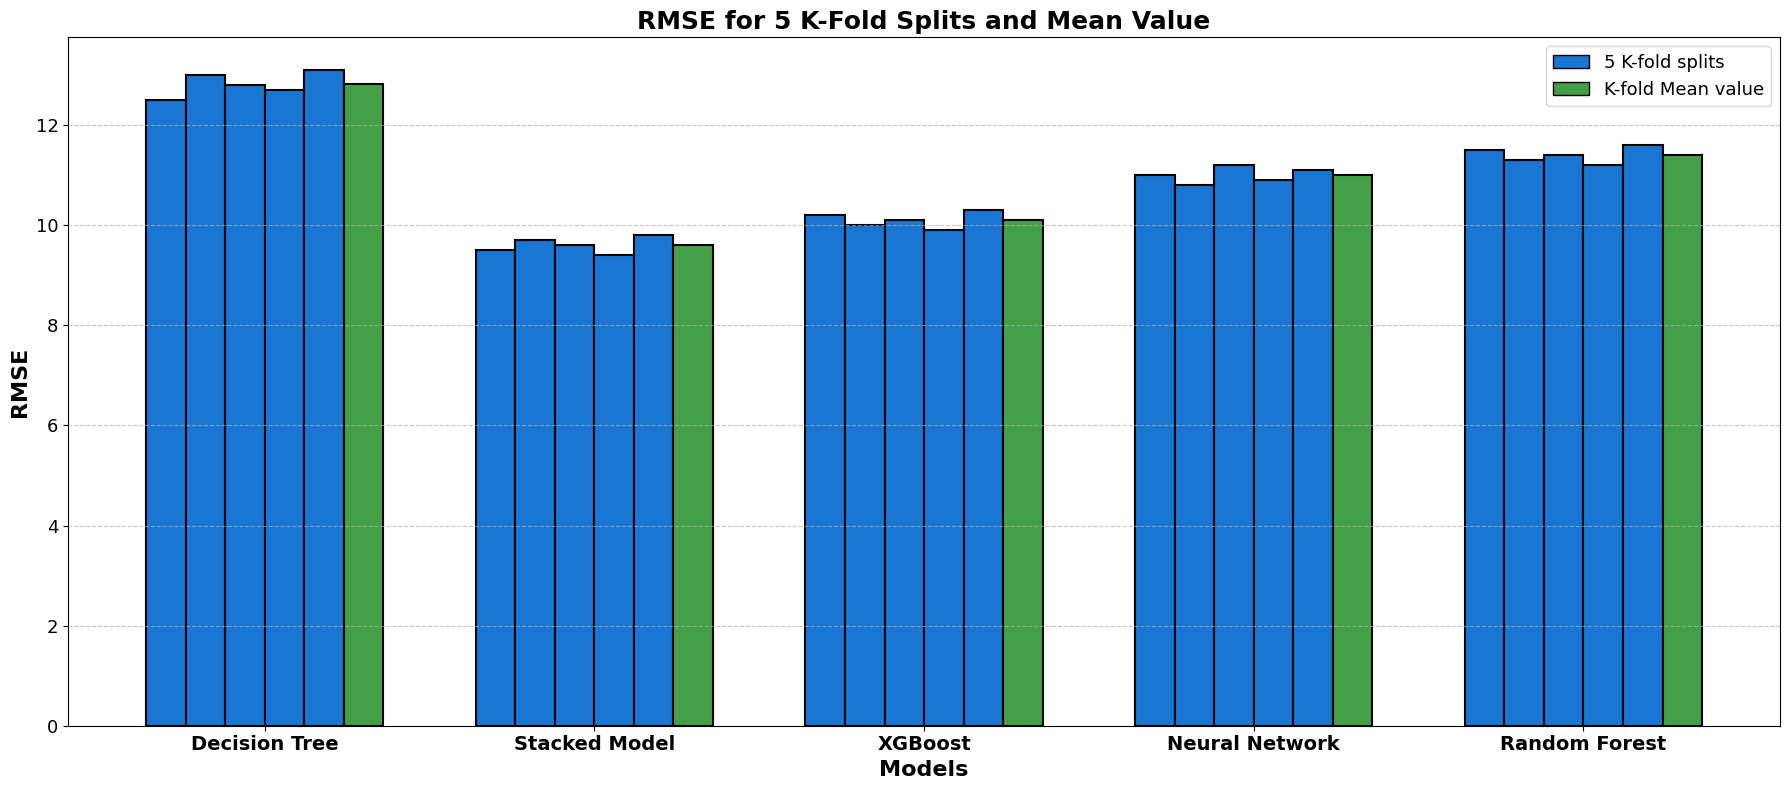

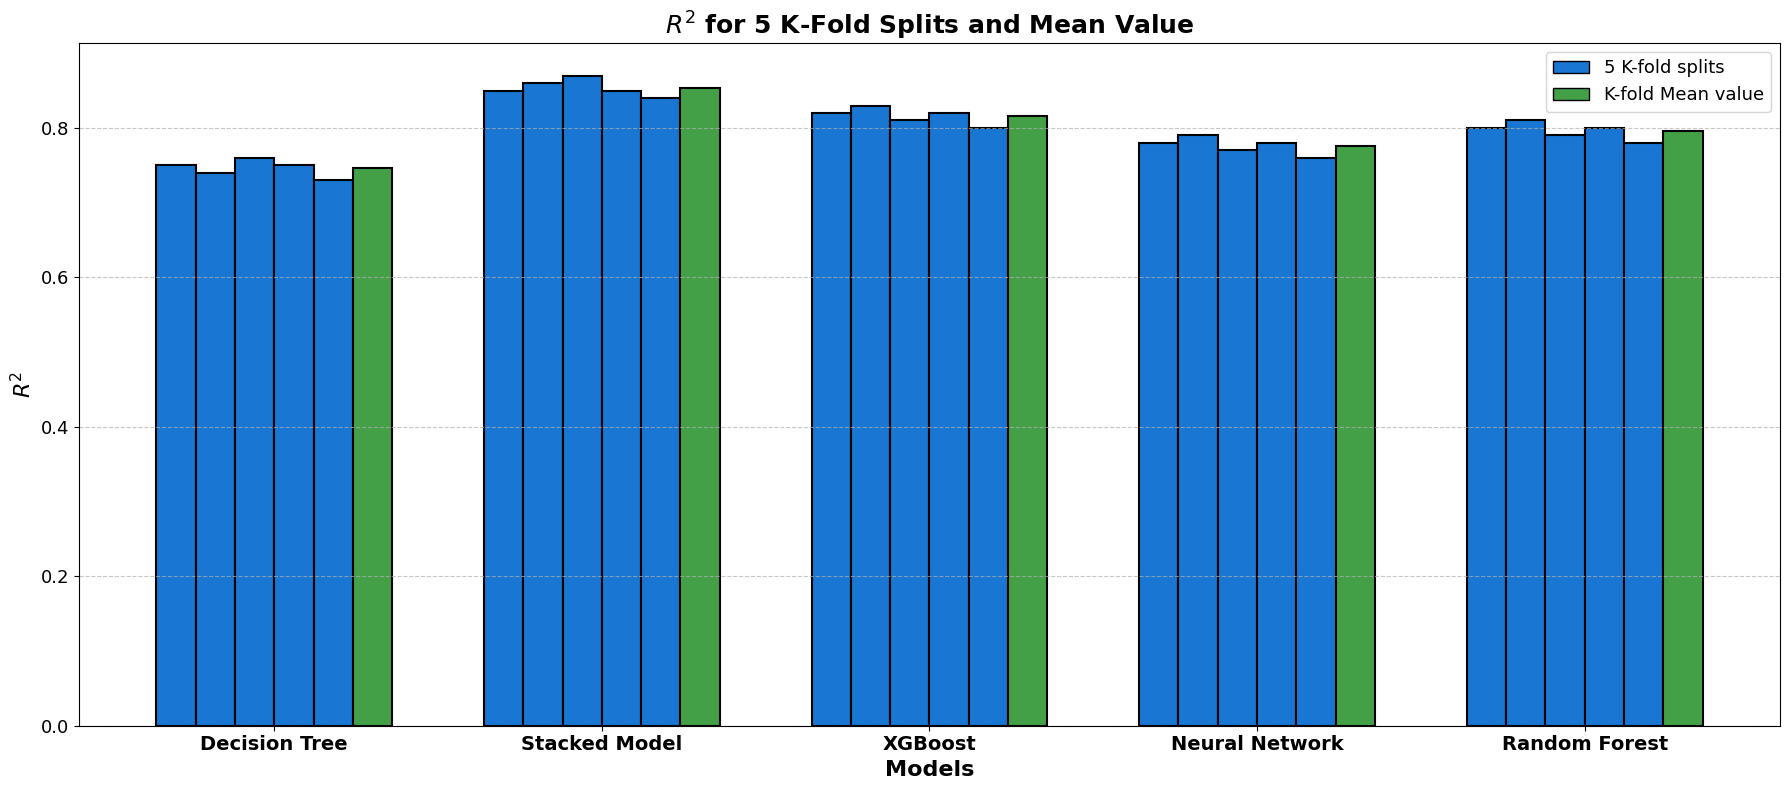

In [74]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

models = ['Decision Tree', 'Stacked Model', 'XGBoost', 'Neural Network', 'Random Forest']

rmse_values = {
    'Decision Tree': [12.5, 13.0, 12.8, 12.7, 13.1],
    'Stacked Model': [9.5, 9.7, 9.6, 9.4, 9.8],
    'XGBoost': [10.2, 10.0, 10.1, 9.9, 10.3],
    'Neural Network': [11.0, 10.8, 11.2, 10.9, 11.1],
    'Random Forest': [11.5, 11.3, 11.4, 11.2, 11.6]
}

r2_values = {
    'Decision Tree': [0.75, 0.74, 0.76, 0.75, 0.73],
    'Stacked Model': [0.85, 0.86, 0.87, 0.85, 0.84],
    'XGBoost': [0.82, 0.83, 0.81, 0.82, 0.80],
    'Neural Network': [0.78, 0.79, 0.77, 0.78, 0.76],
    'Random Forest': [0.80, 0.81, 0.79, 0.80, 0.78]
}

bar_width = 0.12
index = np.arange(len(models))

# Custom legend handles
legend_handles = [
    Patch(facecolor='#1976D2', edgecolor='black', label='5 K-fold splits'),
    Patch(facecolor='#43A047', edgecolor='black', label='K-fold Mean value')
]

# Plot RMSE
plt.figure(figsize=(18, 8))
for i, model in enumerate(models):
    for k in range(5):
        plt.bar(index[i] + bar_width * k, rmse_values[model][k], width=bar_width, color='#1976D2', edgecolor='black', linewidth=1.5)
    plt.bar(index[i] + bar_width * 5, np.mean(rmse_values[model]), width=bar_width, color='#43A047', edgecolor='black', linewidth=1.5)

plt.xlabel('Models', fontsize=16, fontweight='bold')
plt.ylabel('RMSE', fontsize=16, fontweight='bold')
plt.title('RMSE for 5 K-Fold Splits and Mean Value', fontsize=18, fontweight='bold')
plt.xticks(index + bar_width * 2.5, models, fontsize=14, fontweight='bold')
plt.yticks(fontsize=13)
plt.legend(handles=legend_handles, fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot R2
plt.figure(figsize=(18, 8))
for i, model in enumerate(models):
    for k in range(5):
        plt.bar(index[i] + bar_width * k, r2_values[model][k], width=bar_width, color='#1976D2', edgecolor='black', linewidth=1.5)
    plt.bar(index[i] + bar_width * 5, np.mean(r2_values[model]), width=bar_width, color='#43A047', edgecolor='black', linewidth=1.5)

plt.xlabel('Models', fontsize=16, fontweight='bold')
plt.ylabel('$R^2$', fontsize=16, fontweight='bold')
plt.title('$R^2$ for 5 K-Fold Splits and Mean Value', fontsize=18, fontweight='bold')
plt.xticks(index + bar_width * 2.5, models, fontsize=14, fontweight='bold')
plt.yticks(fontsize=13)
plt.legend(handles=legend_handles, fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


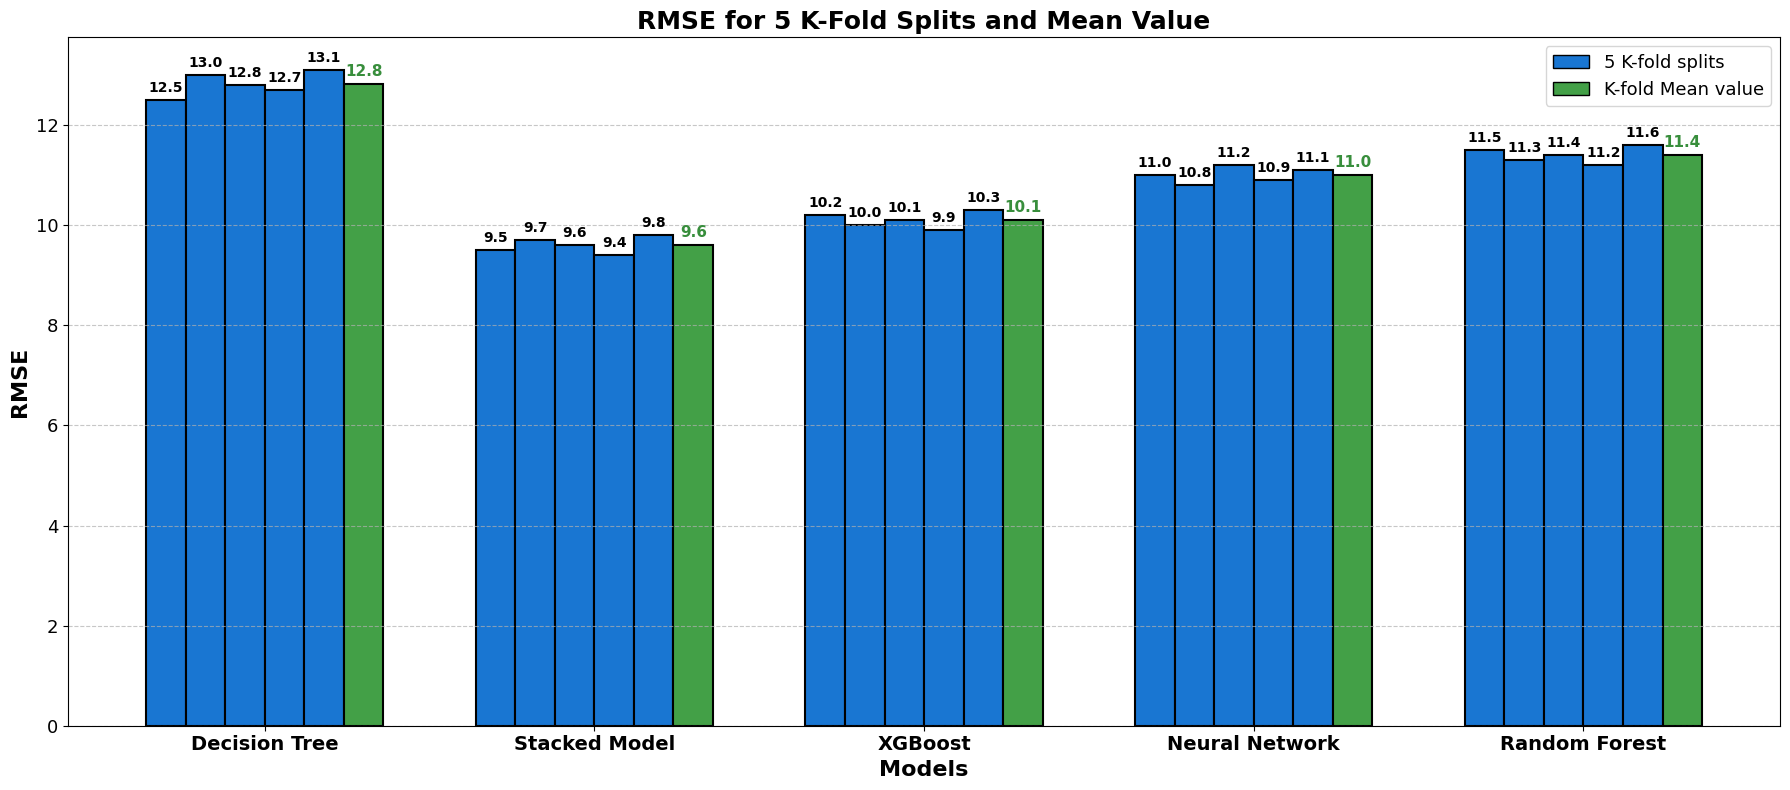

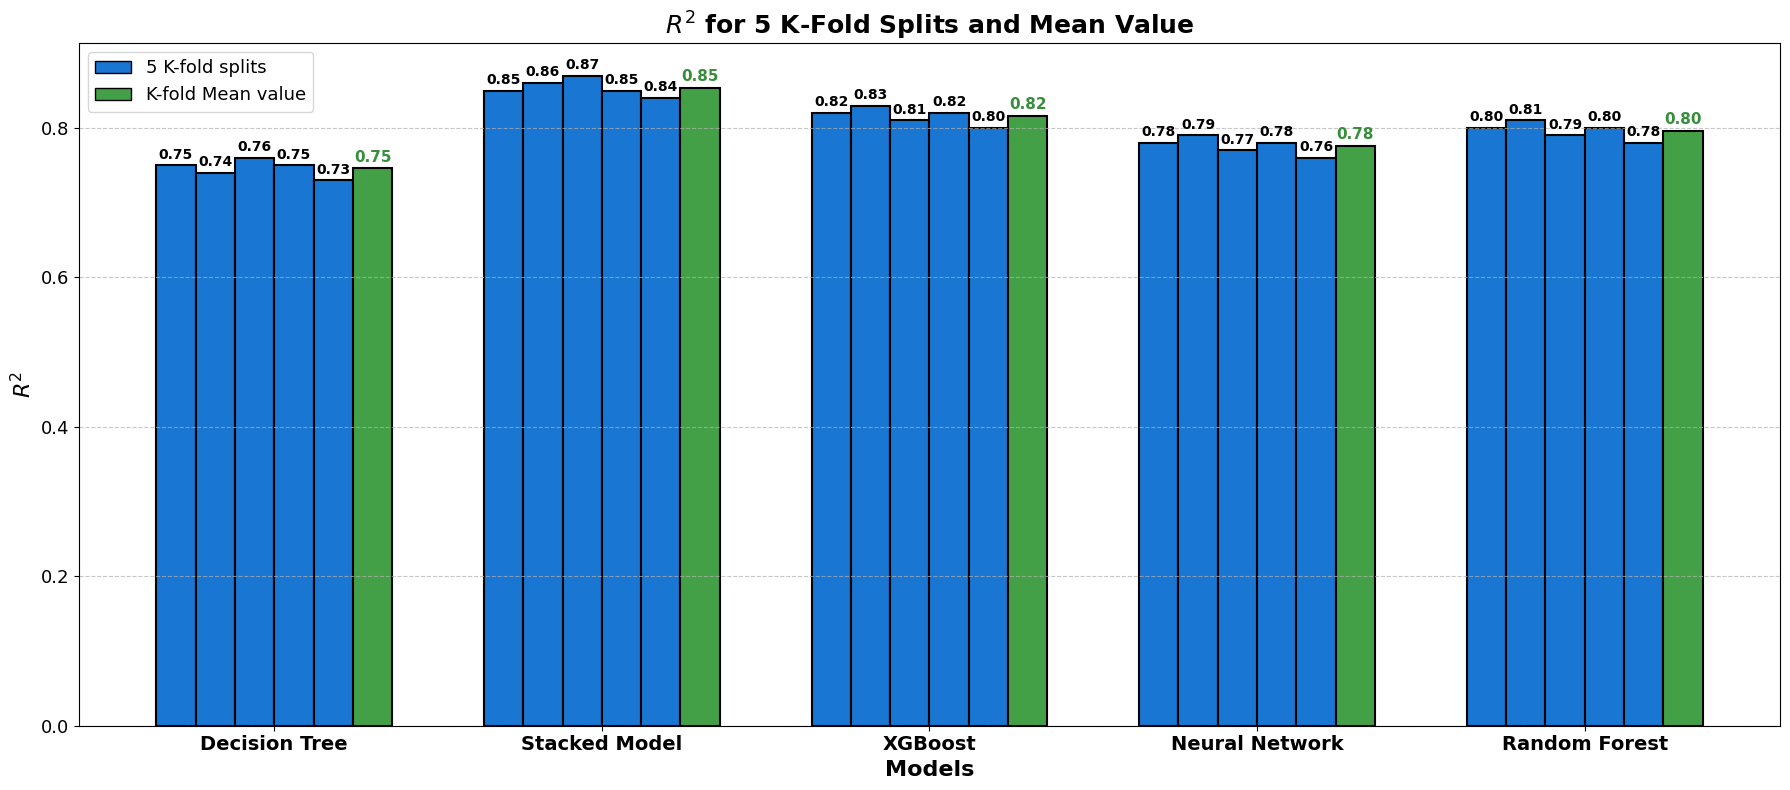

In [78]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

models = ['Decision Tree', 'Stacked Model', 'XGBoost', 'Neural Network', 'Random Forest']

rmse_values = {
    'Decision Tree': [12.5, 13.0, 12.8, 12.7, 13.1],
    'Stacked Model': [9.5, 9.7, 9.6, 9.4, 9.8],
    'XGBoost': [10.2, 10.0, 10.1, 9.9, 10.3],
    'Neural Network': [11.0, 10.8, 11.2, 10.9, 11.1],
    'Random Forest': [11.5, 11.3, 11.4, 11.2, 11.6]
}

r2_values = {
    'Decision Tree': [0.75, 0.74, 0.76, 0.75, 0.73],
    'Stacked Model': [0.85, 0.86, 0.87, 0.85, 0.84],
    'XGBoost': [0.82, 0.83, 0.81, 0.82, 0.80],
    'Neural Network': [0.78, 0.79, 0.77, 0.78, 0.76],
    'Random Forest': [0.80, 0.81, 0.79, 0.80, 0.78]
}

bar_width = 0.12
index = np.arange(len(models))

# Custom legend handles
legend_handles = [
    Patch(facecolor='#1976D2', edgecolor='black', label='5 K-fold splits'),
    Patch(facecolor='#43A047', edgecolor='black', label='K-fold Mean value')
]

# Plot RMSE
plt.figure(figsize=(18, 8))
for i, model in enumerate(models):
    for k in range(5):
        plt.bar(index[i] + bar_width * k, rmse_values[model][k], width=bar_width, color='#1976D2', edgecolor='black', linewidth=1.5)
        plt.text(index[i] + bar_width * k, rmse_values[model][k] + 0.1, f"{rmse_values[model][k]:.1f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
    plt.bar(index[i] + bar_width * 5, np.mean(rmse_values[model]), width=bar_width, color='#43A047', edgecolor='black', linewidth=1.5)
    plt.text(index[i] + bar_width * 5, np.mean(rmse_values[model]) + 0.1, f"{np.mean(rmse_values[model]):.1f}", ha='center', va='bottom', fontsize=11, fontweight='bold', color='#388E3C')

plt.xlabel('Models', fontsize=16, fontweight='bold')
plt.ylabel('RMSE', fontsize=16, fontweight='bold')
plt.title('RMSE for 5 K-Fold Splits and Mean Value', fontsize=18, fontweight='bold')
plt.xticks(index + bar_width * 2.5, models, fontsize=14, fontweight='bold')
plt.yticks(fontsize=13)
plt.legend(handles=legend_handles, fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot R2
plt.figure(figsize=(18, 8))
for i, model in enumerate(models):
    for k in range(5):
        plt.bar(index[i] + bar_width * k, r2_values[model][k], width=bar_width, color='#1976D2', edgecolor='black', linewidth=1.5)
        plt.text(index[i] + bar_width * k, r2_values[model][k] + 0.005, f"{r2_values[model][k]:.2f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
    plt.bar(index[i] + bar_width * 5, np.mean(r2_values[model]), width=bar_width, color='#43A047', edgecolor='black', linewidth=1.5)
    plt.text(index[i] + bar_width * 5, np.mean(r2_values[model]) + 0.005, f"{np.mean(r2_values[model]):.2f}", ha='center', va='bottom', fontsize=11, fontweight='bold', color='#388E3C')

plt.xlabel('Models', fontsize=16, fontweight='bold')
plt.ylabel('$R^2$', fontsize=16, fontweight='bold')
plt.title('$R^2$ for 5 K-Fold Splits and Mean Value', fontsize=18, fontweight='bold')
plt.xticks(index + bar_width * 2.5, models, fontsize=14, fontweight='bold')
plt.yticks(fontsize=13)
plt.legend(handles=legend_handles, fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
